# Cambios semánticos en iniciativas legislativas de ley sobre SALUD
## Caso de uso: MUERTE SÚBITA
Motivación: [Normas sanitarias nacionales y provinciales asociadas a RCP y MUERTE SÚBITA de Argentina](https://public.tableau.com/app/profile/amalia.guaymas/viz/RCP-muertesubitanormas-base/Presentacin?publish=yes)

**Hasta el 2025**
* [Normativa asociada a la palabra RCP: 3 normas nacionales](http://www.legisalud.gov.ar/atlas/categorias/rcp.html)
    * 2012 - Ley 26835. Ley de Promoción y Capacitación en las Técnicas de Preanimación Cardiopulmonar Básicas.
    * 2015 - Ley 27159. Sistema de Prevención Integral de Muerte Súbita.
    * 2009 - Resolución 908/2009. Programa Nacional de Reanimación Neonatal y Pediátrica.
* [Normativa asociado a la palabra RCP: 5 normativas nacionales](http://www.legisalud.gov.ar/atlas/categorias/muerte_subita.html)
    * 2015 - Ley 27159. Sistema de Prevención Integral de Muerte Súbita.
    * 2012 - Ley 26835. Ley de Promoción y Capacitación en las Técnicas de Preanimación Cardiopulmonar Básicas.
    * 2001 - Ley 25501. Programa Nacional de Prevención de las Enfermedades Cardiovasculares.
    * 2009 - Decreto 223/2010. Reglamentación de la ley 25501.
    * 2009 - Resolución 908/2009. Programa Nacional de Reanimación Neonatal y Pediátrica.
    * 2016 - Resolución 182-E/2016. Semana de la Lucha contra la Muerte Súbita.

Para ver por provincias: [Base SAIJ de Normativa Provincial](https://datos.jus.gob.ar/dataset/base-saij-de-normativa-provincial)

### Objetivo general: 
Analizar el cambio semántico en los títulos de iniciativas legislativas de ley sobre
salud generados en la Cámara de Diputados de la Nación Argentina entre
2009 y 2024 (período parlamentario 127 a 141) usando PLN aplicado a corpus
pequeños y datos abiertos con enfoque en uso responsable de algoritmos.

Para el objetivo de detectar y analizar términos con cambios semánticos, se
generaron corpus para tres períodos de tiempos cada uno de cinco años, para
luego generar vectores de palabras que se compararán teniendo en cuenta
el enfoque de Procruste y la menor distancia de similaridad de coseno entre
palabras y pares de períodos.

### EDA
INICIATIVA LEGISLATIVA DE SALUD

La “iniciativa legislativa”, es la facultad de presentar proyectos, corresponde a los diputados, senadores y al presidente de la Nación.
Hay distintos tipos de proyectos, los que se analizaron fueron, los proyectos de ley, destinados a crear, modificar, sustituir o abrogar una ley, institución o norma de caracter general.
* Se compararon tres periodos :
    * Período 2009: [2009,2014)
    * Período 2014: [2014,2019)
    * Período 2019:  [2019,2024) 
* Iniciativas total : 2848 proyectos sobre salud (8% del total 35179)
* Vocabulario: 3221 (25% del total 35179)
* Top 5 palabras con mayores frecuencias:  
nacional (836), creacion (628), programa (488), regimen	(485), salud (483). 

* N-gramas más frecuentes top 6 (mas diferencia con el resto). Se observa n-gramas de n entre 2 a 5 con mínima frecuencia 1: 
	* programa nacional  (2-grama)     208 veces
	* medico obligatorio (2-grama)     187 veces
	* programa medico obligatorio (3-grama)         153 veces
	* programa medico         153 veces
	* obligatorio pmo         150 veces
	* medico obligatorio pmo  150 veces

### Consideraciones previas
Se realizaron 50 ejecuciones independientes del enfoque Procrustes, cada una con una semilla aleatoria distinta. En cada iteración, se seleccionaron las 300 palabras con mayor cambio semántico entre los pares de períodos comparados, considerando únicamente aquellas con al menos 5 ocurrencias en alguno de los dos períodos de cinco años.

Posteriormente, se calculó la similaridad semantica promedio (medida de estabilidad del modelo) para cada palabra identificada en cada par de periodos comparados. Este valor fue estimado junto con sus respectivos intervalos de confianza del 95%, utilizando el método bootstrap.


**Umbrales cables**
* umbral_top = 0 # antes 5 se eliminan las palabras nacional (836), creacion (628), programa (488), regimen	(485), salud (483). 
* umbral_frec_menos = 2 # < antes 5 mediana de frecuencia de ocurrencia de palabra en titulos 
* umbral_frec_menos_full  = 5 # antes 9 < amedia de ocurrencia de palabra en periodo de 5 años
* topn_vecinos = 100

**Config modelo**

https://radimrehurek.com/gensim/models/word2vec.html

* tam_vector = 100 # Dimensionalidad de los vectores de palabras.
* ventana = 8 # ventana ( int , opcional ): distancia máxima entre la palabra actual y la palabra prevista dentro de una oración.
* min_frec = 2 #  Ignora todas las palabras con una frecuencia total menor que esta.
* w = 1  # utilice estos muchos subprocesos de trabajo para entrenar el modelo (=entrenamiento más rápido con máquinas de múltiples núcleos).
* s = 1 # Algoritmo de entrenamiento: 1 para skip-gram; de lo contrario, CBOW.
* e = 100 # Número de iteraciones (épocas) en el corpus. (Anteriormente: iter )
* semilla = 1 # seed ( int , opcional ): Semilla para el generador de números aleatorios. 
* iteracion = 50

**Terminología**
* Par de periodos (2009, 2014) : Esto indica los pares de periodos comparados [2009, 2014) vs  [2014, 2019)
* Par de periodos (2014, 2019) : Esto indica los pares de periodos comparados [2014, 2019) vs [2019, 2024)



 

In [1]:
# Importar librería
from dotenv import load_dotenv
import pandas as pd
import numpy as np
import pickle
import os
import re
import random as rn
import datetime
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import bootstrap
import matplotlib.pyplot as plt
import itertools

from gensim.models import Word2Vec
from tqdm import tqdm
from sklearn.metrics.pairwise import cosine_similarity
tqdm.pandas()

from ast import literal_eval

In [2]:
# Configurar
load_dotenv() # Cargar las variables de entorno del archivo .env
BASE_DIR =  os.getenv("DIR_BASE")
RESULTADOS_DIR = os.getenv("DIR_DATOS_PROCESADOS") # Acceder a las variables de entorno
modelo_dir =  RESULTADOS_DIR+ '/archivos_out/modelos_swmwosge_1008211100'
pd.set_option('display.max_colwidth', None)

In [3]:
# Abrir OBJETO
with open(modelo_dir+'/top300_periodos_procrustes_df.pkl', 'rb') as file: 
    topn_periodo = pickle.load(file) ## Diccionario

In [4]:
pares_periodo = [ (2009, 2014),(2014, 2019)]
topk = 10
for par_periodo in pares_periodo:

    df = topn_periodo[par_periodo].sort_values('similaridad_semantica_mean', ascending=True)
    print("*************************")
    print(par_periodo)
    print("*************************")
    print(df.shape)
    display(df.head(topk))
    display(df.describe(include='all'))
   

*************************
(2009, 2014)
*************************
(341, 6)


,par_periodo,palabra,similaridad_semantica_mean,similaridad_semantica_confidence_intervals,vt1_top10,vt2_top10
185,"(2009, 2014)",legal,0.226934,"(0.22002384660263957, 0.23402394056119352)","{norma, odontologia, auxiliar, loteria, musicoterapia, colaborador}","{embarazo, misoprostol, monodroga, droga}"
81,"(2009, 2014)",declaracion,0.240741,"(0.23132365204190666, 0.25030950875089053)","{rioja, jujuy, departamento, natural, accion, valle, chaco}","{valor, prepagar, marco, suspension}"
196,"(2009, 2014)",materia,0.284821,"(0.27599544304365015, 0.2939124981934813)","{postraumatico, fortalecimiento, primaria, estr, presupuesto, delito, basica, adopcion}","{laboratorio, politica, vacunacion, congreso, cumplimiento}"
118,"(2009, 2014)",empleo,0.324193,"(0.3157658079543117, 0.33340039425717294)","{nivel, jefe, comunitario, familia, equivalente, hogar}","{asignacion, subsistema, elemento, ftalato, contributivo, sustancia, formacion}"
324,"(2009, 2014)",tipo,0.353474,"(0.3457579396706319, 0.3610847644949076)","{papiloma, causado, gripe, influenza, aparicion, virus, h1n1, avance}","{ensenanza, fabricacion, mercurio, cualquiera}"
174,"(2009, 2014)",ingreso,0.374986,"(0.3668127609121415, 0.3828470467135649)","{geriatrico, ganancia, ninez, ciudadano, fincini, anses}","{maquina, ninez, categoria, solar, virus}"
323,"(2009, 2014)",territorio,0.382965,"(0.37243684312347564, 0.39260252943863166)","{corriente, lavanderia, percloroetileno, reconocer, tintoreria}","{restaurante, republica, natural, tecnologico}"
4,"(2009, 2014)",acompanante,0.385151,"(0.37867500185855757, 0.39201489404050754)","{embarazo, gratuidad, proceso, recien, parto, nacimiento, permanencia}","{cosmiatrio, equinoterapia, obstetricia, cosmetologia, piercing, terapeutico, recurso}"
84,"(2009, 2014)",dengue,0.393630,"(0.38788975113805113, 0.3991380240805996)","{seguimiento, aparicion, tropical, territorio, epidemia, chaco, emergente}","{fiebre, virus, comprendido}"
65,"(2009, 2014)",comunitario,0.402430,"(0.3924988968362833, 0.4114690451141395)","{militar, voluntario, revestir, direccion, sanitaria, radicacion, hogar}","{financiero, familia, accion, marzo}"


,par_periodo,palabra,similaridad_semantica_mean,similaridad_semantica_confidence_intervals,vt1_top10,vt2_top10
count,341,341,341.000000,341,341,341
unique,1,341,NaN,341,340,341
top,"(2009, 2014)",legal,NaN,"(0.22002384660263957, 0.23402394056119352)","{tgd, integrante, generalizado}","{embarazo, misoprostol, monodroga, droga}"
freq,341,1,NaN,1,2,1
mean,NaN,NaN,0.628807,NaN,NaN,NaN
std,NaN,NaN,0.097842,NaN,NaN,NaN
min,NaN,NaN,0.226934,NaN,NaN,NaN
25%,NaN,NaN,0.572572,NaN,NaN,NaN
50%,NaN,NaN,0.659745,NaN,NaN,NaN
75%,NaN,NaN,0.705454,NaN,NaN,NaN


*************************
(2014, 2019)
*************************
(333, 6)


,par_periodo,palabra,similaridad_semantica_mean,similaridad_semantica_confidence_intervals,vt1_top10,vt2_top10
101,"(2014, 2019)",dispositivo,0.219099,"(0.2116572594670913, 0.2265566385301449)","{similar, necesario, nocivo, dato, electronico}","{minimo, oftalmologico, concurrencia, tecnologico, instalacion, desfibrilador, subitar}"
67,"(2014, 2019)",comunitario,0.281564,"(0.27165948468648776, 0.290427646180417)","{financiero, familia, accion, marzo}","{fortalecimiento, organizacion, presupuesto, escolar, objeto, agente, trabajador, reconocimiento}"
5,"(2014, 2019)",adecuado,0.286341,"(0.27825804628988354, 0.2936208116061226)","{rotulacion, medicinal, camara, especialidad}","{geriatrico, congreso, tumor, hijo, manejo, paliativo}"
0,"(2014, 2019)",accesibilidad,0.298858,"(0.28724259050712, 0.3092740195772763)","{extension, consentimiento, movilidad, discapacitada}","{elemento, trabajo, gestion, digno, dato}"
148,"(2014, 2019)",forma,0.319486,"(0.3096475531507553, 0.32785450295506097)","{transmision, proteina, complemento, cualquiera}","{actualizacion, correspondiente, organizacion, modelo, domiciliario}"
316,"(2014, 2019)",tipo,0.321460,"(0.31196973834101954, 0.33083859218558054)","{ensenanza, fabricacion, mercurio, cualquiera}","{visual, judicial, diabetes, droga, braille, identificacion}"
157,"(2014, 2019)",gratuidad,0.331567,"(0.3218824423680031, 0.34121944977961777)","{calendario, vacuna, vacunacion, comprendido}","{agua, presupuesto, potable, afiliado, pensionado}"
105,"(2014, 2019)",domiciliario,0.347000,"(0.33851897545910237, 0.35594063820341443)","{inssjp, vencido, recoleccion, medicamento}","{forma, educacion, organizacion, ter, financiero}"
231,"(2014, 2019)",obligacion,0.373731,"(0.3656400425561812, 0.38094089837290473)","{profesion, afiliado, especialidad, congreso, cumplimiento, farmaceutico}","{animal, judicial, sangre, alcoholica, donante}"
224,"(2014, 2019)",necesario,0.374349,"(0.36594618141845137, 0.38315810094567526)","{dispositivo, precio, concurrencia, externo, existir, desfibrilador, subitar}","{precio, manejo, principio}"


,par_periodo,palabra,similaridad_semantica_mean,similaridad_semantica_confidence_intervals,vt1_top10,vt2_top10
count,333,333,333.000000,333,333,333
unique,1,333,NaN,333,333,333
top,"(2014, 2019)",dispositivo,NaN,"(0.2116572594670913, 0.2265566385301449)","{similar, necesario, nocivo, dato, electronico}","{minimo, oftalmologico, concurrencia, tecnologico, instalacion, desfibrilador, subitar}"
freq,333,1,NaN,1,1,1
mean,NaN,NaN,0.627456,NaN,NaN,NaN
std,NaN,NaN,0.102706,NaN,NaN,NaN
min,NaN,NaN,0.219099,NaN,NaN,NaN
25%,NaN,NaN,0.566346,NaN,NaN,NaN
50%,NaN,NaN,0.647331,NaN,NaN,NaN
75%,NaN,NaN,0.709830,NaN,NaN,NaN


* Palabras seleccionadas de la comparación entre pares de períodos (2009, 2014) es decir [2009,2014) vs [2014, 2019)
    * 341 palabras
    * similaridad_semantica_mean
        * media: 0.628807
        * mediana: 0.659745

* Palabras seleccionadas de la comparación entre pares de períodos (2014, 2019) es decir [2014,2019) vs [2019, 2024)

    * 333 palabras
    * similaridad_semantica_mean
        * media: 0.627456
        * mediana: 0.6473315


En general, por el promedio de similaridad semántica (0.628807 y 0.627456), no se observan cambios semánticos en las palabras identificadas en las top 300 palabras comparadas entre pares de períodos, es decir entre (2009 , 2014)  y (2014, 2019).

### Palabras identificadas o asociadas con muerte súbita

In [5]:
# ms palabras
ms_palabras = ['desfibrilador','cardiopulmonar','cardioasistido','cardio','subitar','subita','dea','dispositivo', 'muerte','vida','vivir','morir','capacitarcion','capacitar','capacita',
               'emergencia','supervivencia','reanimacion','prevencion','incidencia']


### Distribución entre pares de períodos


#### Identificar las palabras con cambio semántico importante y moderado

Identificar las palabras que aparecen consistentemente como cambiantes. Tener en cuenta la el promedio de similitud coseno por palabras basada en las 50 iteraciones, la selección de los top 300 palabras con al menos cinco ocurrencia en alguno de los periodos comparados.

Umbrales:

* Cambio fuerte: similitud coseno <= 0.3
* Cambio moderado:  0.3 y 0.5


Tener en cuenta si Distancia = 1 - similitud coseno (sc). También se lo puede interpretar como: 

* dist ~ 0.0 (sc ~ 1)	 La palabra no cambió su significado
* dist ~ 0.5 (sc ~ 0.5)  Cambio moderado
* dist > 0.7 (sc <= 0.3) Cambio fuerte (usos muy distintos)

In [6]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

# Convertir datos en DataFrame para visualización
def plot_heatmap(cambios_df, title, top = 10):
    #words, values = zip(*changed_words[:top])  # Tomamos el top 10
    #df = pd.DataFrame({"Palabra": words, "Cambio Semántico": values})
    df = cambios_df.copy()
    plt.figure(figsize=(8, 5))
    sns.heatmap(df.set_index("palabra").T, cmap="Reds", annot=True, fmt=".2f", linewidths=0.5)
    plt.title(title)
    plt.show()

def diferencia(par):
    return par[1] - par[0]

* https://www.argentina.gob.ar/salud/glosario/prevencion-de-muerte-subita
* https://www.ospedyc.org/40-000-casos-anuales-de-muerte-subita-en-argentina/

(2009, 2014)


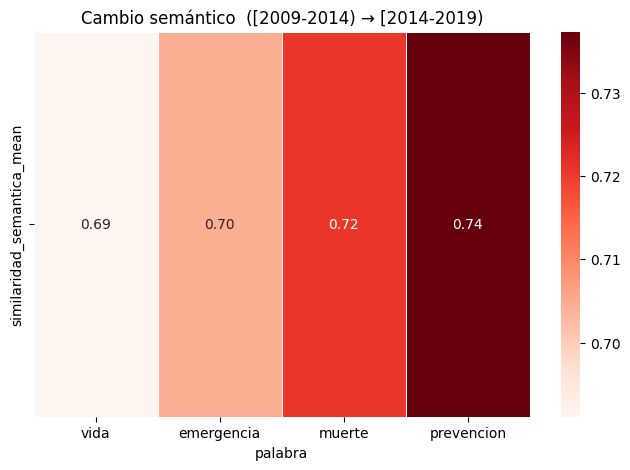

,par_periodo,palabra,similaridad_semantica_mean,similaridad_semantica_confidence_intervals,vt1_top10,vt2_top10,dispersion
333,"(2009, 2014)",vida,0.691119,"(0.6855481360372228, 0.6969682632293934)","{embarazo, puerperio, parto, consultoria, mistanasica}","{caso, digno, fibromialgia, calidad, familia, paliativo}",0.011420
117,"(2009, 2014)",emergencia,0.704497,"(0.695627929562879, 0.711524332928565)","{zona, medioambiental, chaco, prorrogable}","{prorrogable, termino, medioambiental, agropecuario, productivo, cordoba}",0.015896
216,"(2009, 2014)",muerte,0.720690,"(0.7157408574582953, 0.7250243583271004)","{digno, espacio, judicial, informado, historia, paliativo, subitar}","{digno, escolar, natural, comision, paliativo, subitar}",0.009284
257,"(2009, 2014)",prevencion,0.737291,"(0.7353887799999999, 0.7393838199999999)","{seguimiento, acvo, transmisibl, cerebrovascular, delito}","{dengue, exposicion, acvo, cerebrovascular, comite, acv, accidente, fiebre}",0.003995


(2014, 2019)


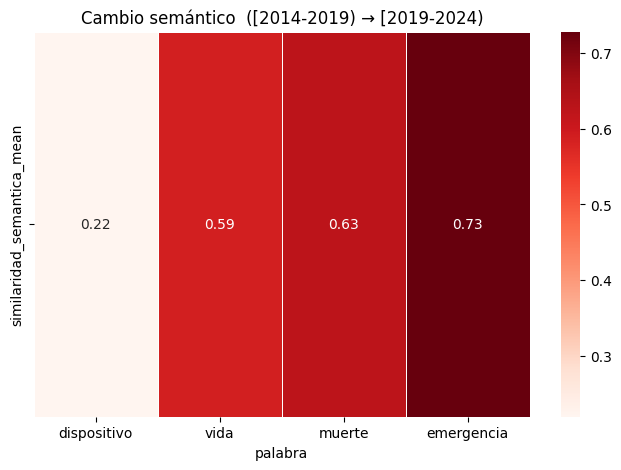

,par_periodo,palabra,similaridad_semantica_mean,similaridad_semantica_confidence_intervals,vt1_top10,vt2_top10,dispersion
101,"(2014, 2019)",dispositivo,0.219099,"(0.2116572594670913, 0.2265566385301449)","{similar, necesario, nocivo, dato, electronico}","{minimo, oftalmologico, concurrencia, tecnologico, instalacion, desfibrilador, subitar}",0.014899
327,"(2014, 2019)",vida,0.589092,"(0.5816220243979449, 0.5975310361457339)","{caso, digno, fibromialgia, calidad, familia, paliativo}","{geriatrico, encontrar, embarazado, paliativo, establecido}",0.015909
217,"(2014, 2019)",muerte,0.626481,"(0.6188753448996076, 0.6338025869876674)","{digno, escolar, natural, comision, paliativo, subitar}","{asistido, digno, natural, subitar}",0.014927
120,"(2014, 2019)",emergencia,0.728426,"(0.7200668120531111, 0.7351552202955262)","{prorrogable, termino, medioambiental, agropecuario, productivo, cordoba}","{prorrogable, desastre, sanitario, departamento, zona, chaco}",0.015088


In [7]:
for par_periodo in pares_periodo:
    periodo_df = topn_periodo[par_periodo]
     
    print(par_periodo)
    periodo_df1 =  periodo_df[periodo_df['palabra'].isin(ms_palabras)].sort_values('similaridad_semantica_mean', ascending=True)
    periodo_df1["dispersion"] = periodo_df1['similaridad_semantica_confidence_intervals'].apply(diferencia)

    # Graficar Heatmaps
    plot_heatmap(periodo_df1[['palabra','similaridad_semantica_mean']], "Cambio semántico  (["+str(par_periodo[0])+"-"+str(par_periodo[1])+") → ["+str(par_periodo[1])+"-"+str(par_periodo[1]+5)+")", top=topk)
    display(periodo_df1) 
    

**Muerte súbita**
* El término 'dispositivo' presenta cambio semántico fuerte ( 0.219099), en el par de periodos comparados (2014,2019). Observando sus tops 10 palabras más asociadas en el periodo 2019 (2019-2023) aparecen las palabras "desfibrilador" y "subitar".
* Del análisis anterior se identifico que el término 'pais' y 'necesario' que presentan cambios semánticos moderados en el par de periodos comparados (2014,2019) están relacionados con muerte súbita porque entre sus vecindades de palabras aparece la palabra "desfibrilador".
* Las palabras muerte y vida no se identifican como 'palabra con cambio semántico ni fuerte ni moderado' ya que sus valores asociados son superiores a 0.5 de similitud coseno. Se observa que disminuye el valor de similaridad en relacion al orden de comparación por periodos, lo que indica que disminuye en relación al avance de los años.

    * Palabra : dispositivo
        * 2014-2019: 0.219099
    * Palabra : prevencion
        * 2009-2014: 0.737291
    * Palabra : emergencia
        * 2009-2014: 0.704497
        * 2014-2019: 0.728426
    * Palabra : vida
        * 2009-2014: 0.691119
        * 2014-2019: 0.589092
    * Palabra : muerte
        * 2009-2014: 0.720690
        * 2014-2019: 0.626481


##### Palabras comunes en entre todos los pares de períodos comparados


In [8]:
palabra_comun = set(topn_periodo[(2009, 2014)]['palabra'].unique()) & set(topn_periodo[(2014, 2019)]['palabra'].unique()) & set(ms_palabras)
print("Cantidad de palabras en común:",len(palabra_comun))

Cantidad de palabras en común: 3


In [9]:
palabra_comun

{'emergencia', 'muerte', 'vida'}

El término 'emergencia','vida','muerte' no presentan cambios semántico entre los pares de periodos comparados por los umbrales definidos, tal que está presente en todos los periodos comparados.

In [10]:
# Crear directorio para algoritmo de cambio semántico
# Crear directorio modelo alineado
alin_dir = modelo_dir +'/estabilidad_procrustes/alineado/'
i = 0

In [27]:
# Inicializar estructura de vectores por palabra
from collections import defaultdict
vectores_por_palabra = {}
vectores_promedio = {}

def get_vector_modelo(vectores,periodo,i):
    modelo = Word2Vec.load(alin_dir+"alin_" + str(periodo)+'_'+str(i)+'.mdl')
    for palabra in modelo.wv.key_to_index:
        vectores[palabra].append(modelo.wv[palabra])
    return vectores
    
for periodo in [2009,2014,2019]:
    # Por período
    vectores_por_palabra[periodo] = defaultdict(list)
    for i in range(50):
        vectores_por_palabra[periodo] = get_vector_modelo(vectores_por_palabra[periodo],periodo,i)
    #Calcular vector medio solo para palabras con presencia en todas las iteraciones (opcional)
    vectores_promedio[periodo] = {pal: np.mean(vs, axis=0) for pal, vs in vectores_por_palabra[periodo].items() if len(vs) == 50}

In [28]:
# modelos alineados por procuster para iter 0
m_2009 = Word2Vec.load(alin_dir+"alin_" + str(2009)+'_'+str(i)+'.mdl')
m_2014 = Word2Vec.load(alin_dir+"alin_" + str(2014)+'_'+str(i)+'.mdl') 
m_2019 = Word2Vec.load(alin_dir+"alin_" + str(2019)+'_'+str(i)+'.mdl')  
# Para graficar
embeddings_by_period = {}
alineados = {}
base = 2009
vocab = {}
for modelo in [m_2009,m_2014,m_2019]:
    for word in modelo.wv.key_to_index:
        vocab[word] = modelo.wv.get_vector(word)
    embeddings_by_period[base]=  vocab
    alineados[base] = modelo
    base = base + 5

#### Vecindades
La vecindad de una palabra, son las top palabras más asociadas al periodo de 5 años de estudio. Por ejemplo: la palabra 'dispositivo' en el período 2014 estaba más asociado a las palabras {electronico, similar, dato, nocivo, necesario} tal para el período 2019 estaba más relacionado con {desfibrilador, instalacion, tecnologico, subitar, concurrencia, minimo, oftalmologico}.

In [19]:
## 2. Visualización del desplazamiento con t-SNE

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.manifold import TSNE


def compute_cosine_similarity(model1,model2,word):
    vector1 = model1.wv[word].reshape(1,-1)
    vector2 = model2.wv[word].reshape(1,-1)
    return(cosine_similarity(X=vector1, Y=vector2)[0][0])

def reducir_dimensionalidad( embeddings, n_components=2, perplexity=5, palabrasComun = []):
    if len(palabrasComun)>0:
        words = palabrasComun
    else:
        words = list(embeddings.keys())
    
    vectors = np.array([embeddings.wv.get_vector(word)  for word in words])
    #embeddings[word]  
    tsne = TSNE(n_components=n_components, perplexity=perplexity, random_state=42)
    reduced_vectors = tsne.fit_transform(vectors)
    
    return reduced_vectors


def plot_neighbors_tsne(word, embeddings_by_period, alineados,periods, top_k=10):
    all_vectors = []
    all_labels = []
    all_colors = []
    center_coords = {}
    legend_labels = []

    color_map = plt.cm.get_cmap("tab10", len(periods))

    for i, period in enumerate(periods):
        if word not in embeddings_by_period[period]:
            print(f" '{word}' no está en el vocabulario del período {period}")
            continue
        
        center_vec = embeddings_by_period[period][word]
        vocab = embeddings_by_period[period]

   

        palabras_masSim = alineados[period].wv.most_similar(positive=[word], topn=top_k)
        print(period)
        print(palabras_masSim)
        neighbors = [ pal_peso[0] for pal_peso in palabras_masSim]
        #palabras_masSim_period1 = m2.wv.most_similar(positive=[palabra], topn=top_k)
        #neighbors = sorted(sims.items(), key=lambda x: x[1], reverse=True)[:top_k]

        # Agregar el centro y sus vecinos
        all_vectors.append(center_vec)
        all_labels.append(word)  # No mostrar periodo en texto
        all_colors.append(i)
        legend_labels.append((period, period+5))

        for neighbor in neighbors:
            all_vectors.append(vocab[neighbor])
            all_labels.append(neighbor)  # Solo mostrar nombre del vecino
            all_colors.append(i)
            legend_labels.append((period, period+5))

    if not all_vectors:
        print("No hay datos suficientes para graficar.")
        return

    X = np.array(all_vectors)
    tsne = TSNE(n_components=2, perplexity=5
                , random_state=42)
    X_2d = tsne.fit_transform(X)

    plt.figure(figsize=(15, 10))
    scatter_handles = {}
    idx = 0
    for i, period in enumerate(periods):
        if (period, period+5) not in legend_labels:
            continue
        color = color_map(i)
        #etiqueta = "["+str(period)+","+str(period+5)+")"
        etiqueta = str(period)
        handle = plt.scatter([], [], color=color, label=etiqueta)
        scatter_handles[period] = handle

    max_dist = -1
    max_pair = None

    for i, (x, label) in enumerate(zip(X_2d, all_labels)):
        color = color_map(all_colors[i])
        period = legend_labels[i]
        plt.scatter(x[0], x[1], color=color, s=60)
        if label != word:
            plt.text(x[0], x[1], label, fontsize=9)
        else:
            # es el centro, guardar la coordenada
            plt.text(x[0], x[1], label, fontsize=10, color='blue')

   
    plt.title("Vecindades semánticas (top "+str(top_k)+") para "+word)
   
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(modelo_dir+'/estabilidad_procrustes/estabilidad_procrustes_'+word)

    plt.show()

Para garantizar la estabilidad del modelo se ejecutaron 50 iteraciones y se establecieron bajo ciertas restricciones las top 300 palabras más estables posible cambio. Podemos analizar las vecindades teniendo en cuenta dos enfoques: seleccionar una iteracion, como iteración 0 , o considerar la vecindad que resulta de las palabras presente en las 50 iteraciones asociadas a la palabra de interés. Con este último enfoque estamos perdiendo palabras pero a la vez fortaleciendo la interpretación ante palabras que representan un cambio para la palabra de interés.

**Enfoque de explorar la iteración 0**

C:\Users\Usuario\AppData\Local\Temp\ipykernel_16544\1037429804.py:35: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  color_map = plt.cm.get_cmap("tab10", len(periods))


2009
[('externo', 0.985295295715332), ('espacio', 0.8996772170066833), ('automatico', 0.8469588160514832), ('equipo', 0.8346286416053772), ('instalacion', 0.833476185798645), ('dependencia', 0.8318103551864624), ('auxilio', 0.7360955476760864), ('concurrencia', 0.7304520010948181), ('curso', 0.720475435256958), ('pais', 0.7085614800453186)]
2014
[('concurrencia', 0.8936384916305542), ('externo', 0.8606132864952087), ('automatico', 0.8132598996162415), ('existir', 0.7420438528060913), ('area', 0.715445876121521), ('lugar', 0.687947154045105), ('masivo', 0.6835642457008362), ('espacio', 0.6736806631088257), ('instalacion', 0.6649430990219116), ('dependencia', 0.6602512001991272)]
2019
[('automatico', 0.8954947590827942), ('concurrencia', 0.8574222922325134), ('externo', 0.8158692121505737), ('lugar', 0.703531801700592), ('cartel', 0.6934622526168823), ('exhibicion', 0.6840333342552185), ('instalacion', 0.6797686815261841), ('espacio', 0.6594657897949219), ('argentina', 0.6198858022689819

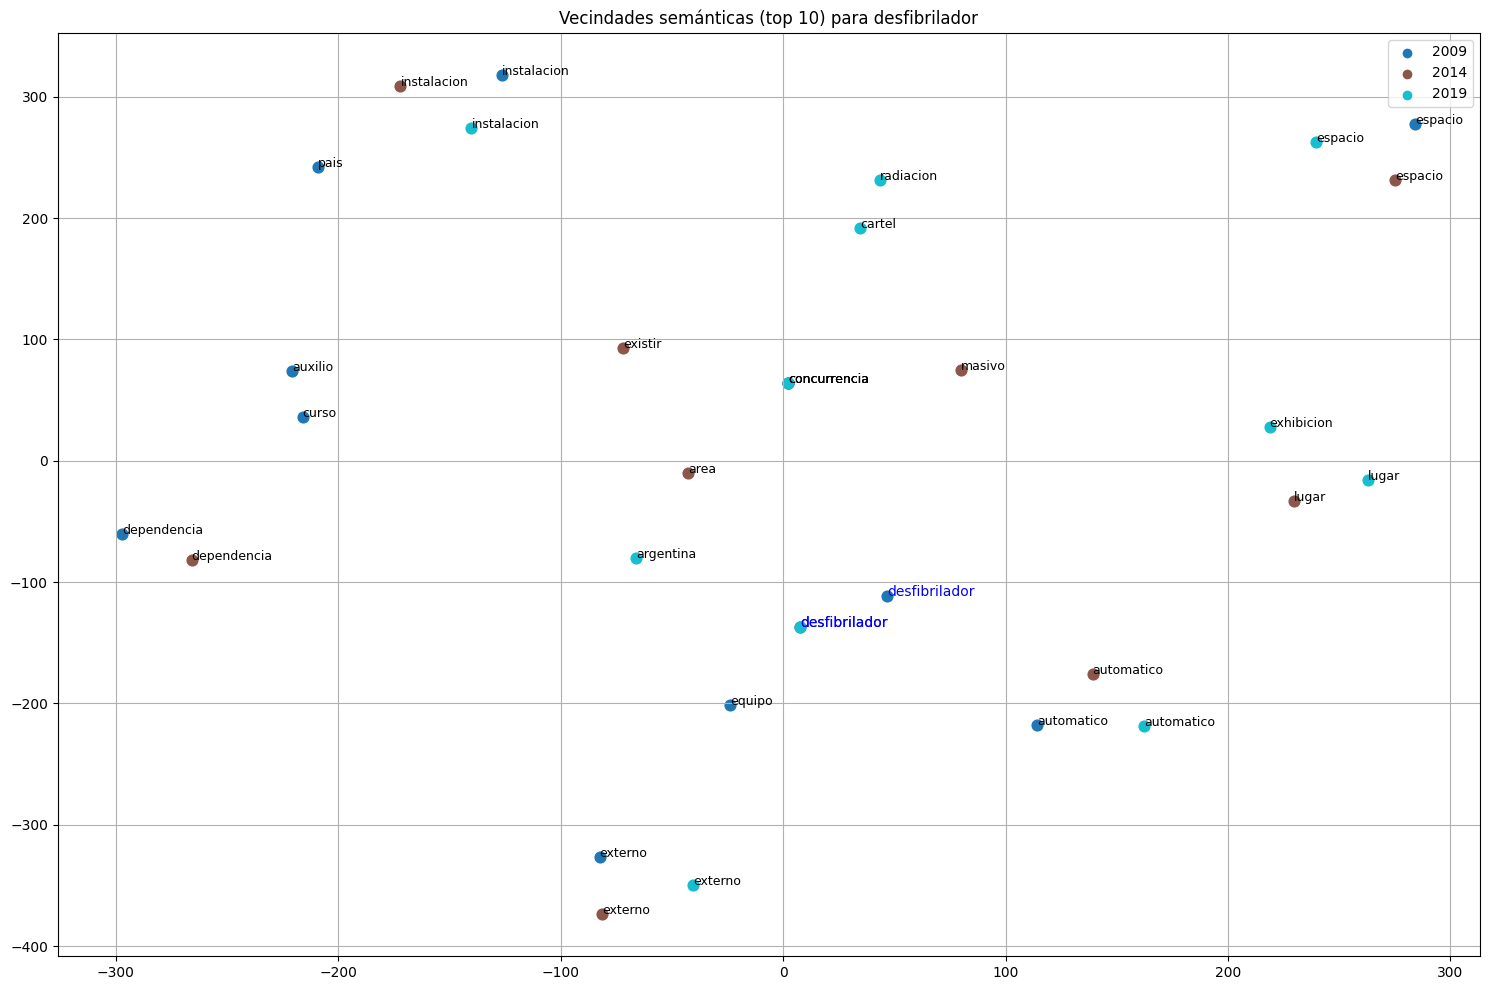

C:\Users\Usuario\AppData\Local\Temp\ipykernel_16544\1037429804.py:35: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  color_map = plt.cm.get_cmap("tab10", len(periods))


 'cardiopulmonar' no está en el vocabulario del período 2009
 'cardiopulmonar' no está en el vocabulario del período 2014
 'cardiopulmonar' no está en el vocabulario del período 2019
No hay datos suficientes para graficar.
 'cardioasistido' no está en el vocabulario del período 2009
 'cardioasistido' no está en el vocabulario del período 2014
 'cardioasistido' no está en el vocabulario del período 2019
No hay datos suficientes para graficar.
 'cardio' no está en el vocabulario del período 2009
 'cardio' no está en el vocabulario del período 2014
 'cardio' no está en el vocabulario del período 2019
No hay datos suficientes para graficar.
2009
[('espacio', 0.8311309218406677), ('muerte', 0.7814270853996277), ('nomenclador', 0.6986482739448547), ('basica', 0.6435211300849915), ('fortalecer', 0.6407893896102905), ('infertilidad', 0.6321448683738708), ('desfibrilador', 0.6266747713088989), ('violencia', 0.6239411234855652), ('posicionamiento', 0.6229147911071777), ('externo', 0.622157573699

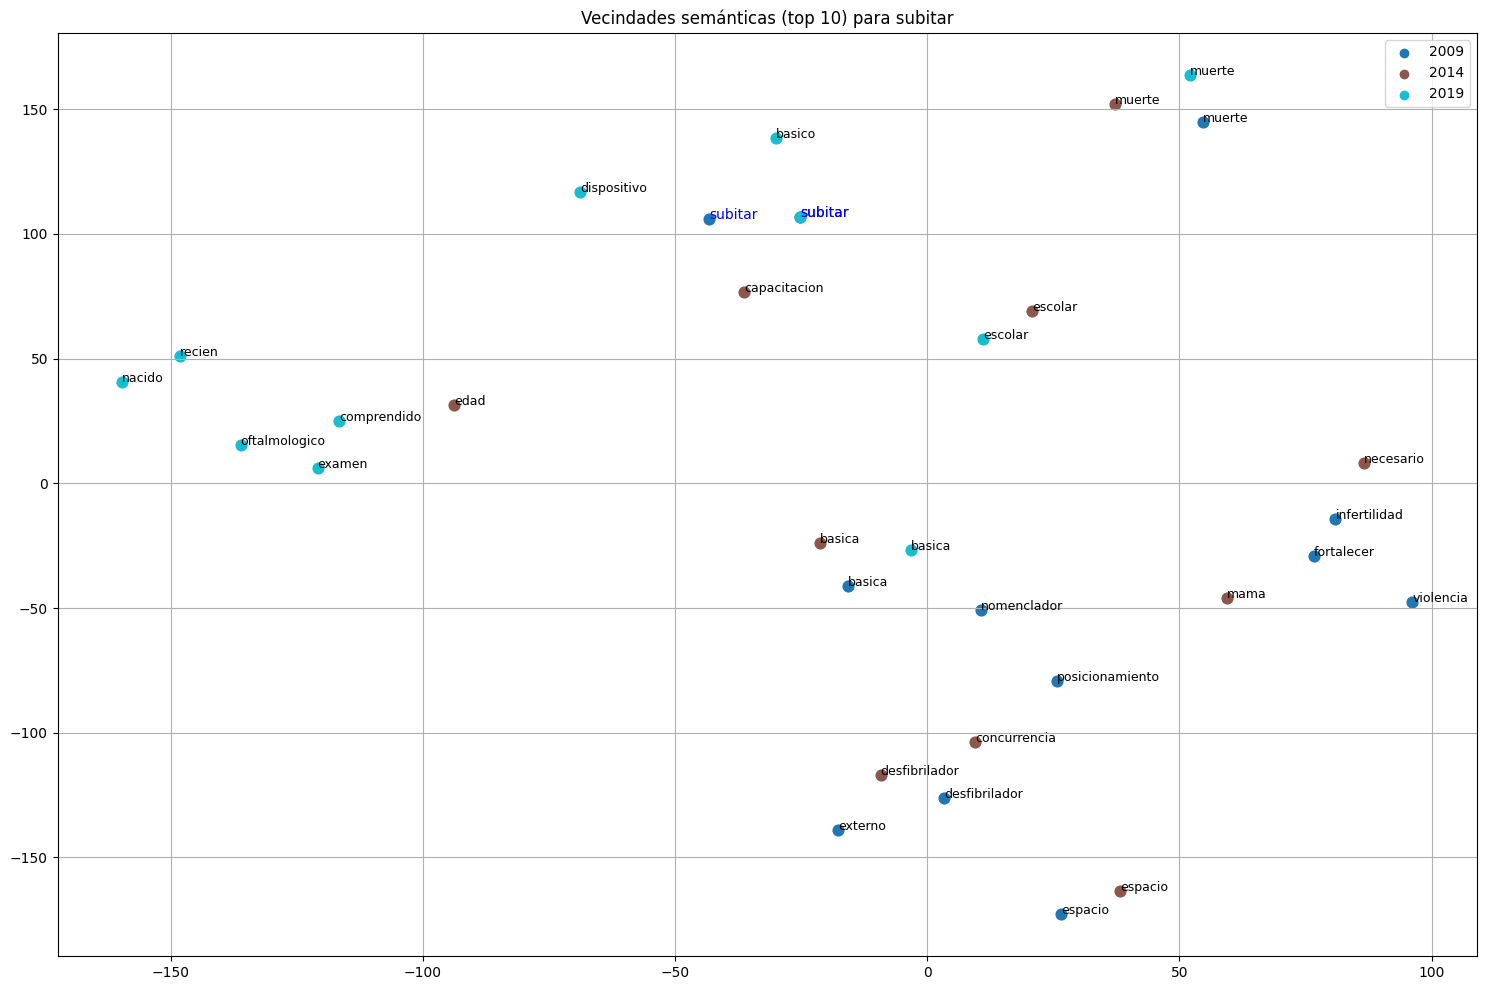

C:\Users\Usuario\AppData\Local\Temp\ipykernel_16544\1037429804.py:35: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  color_map = plt.cm.get_cmap("tab10", len(periods))


 'subita' no está en el vocabulario del período 2009
 'subita' no está en el vocabulario del período 2014
 'subita' no está en el vocabulario del período 2019
No hay datos suficientes para graficar.
 'dea' no está en el vocabulario del período 2009
 'dea' no está en el vocabulario del período 2014
 'dea' no está en el vocabulario del período 2019
No hay datos suficientes para graficar.
2009
[('perdido', 0.8802289366722107), ('musica', 0.8792425394058228), ('audicion', 0.8174654841423035), ('ostomizada', 0.8109687566757202), ('advertencia', 0.8055023550987244), ('reproduccion', 0.7599477171897888), ('movil', 0.7469096779823303), ('pila', 0.6848747730255127), ('bateria', 0.6758443117141724), ('fertilizacion', 0.6263598799705505)]
2014
[('nocivo', 0.7307417392730713), ('electronico', 0.670409083366394), ('similar', 0.6439433693885803), ('necesario', 0.5779457092285156), ('transgenico', 0.5682541728019714), ('dato', 0.5642356872558594), ('efecto', 0.5503780841827393), ('receta', 0.54113030

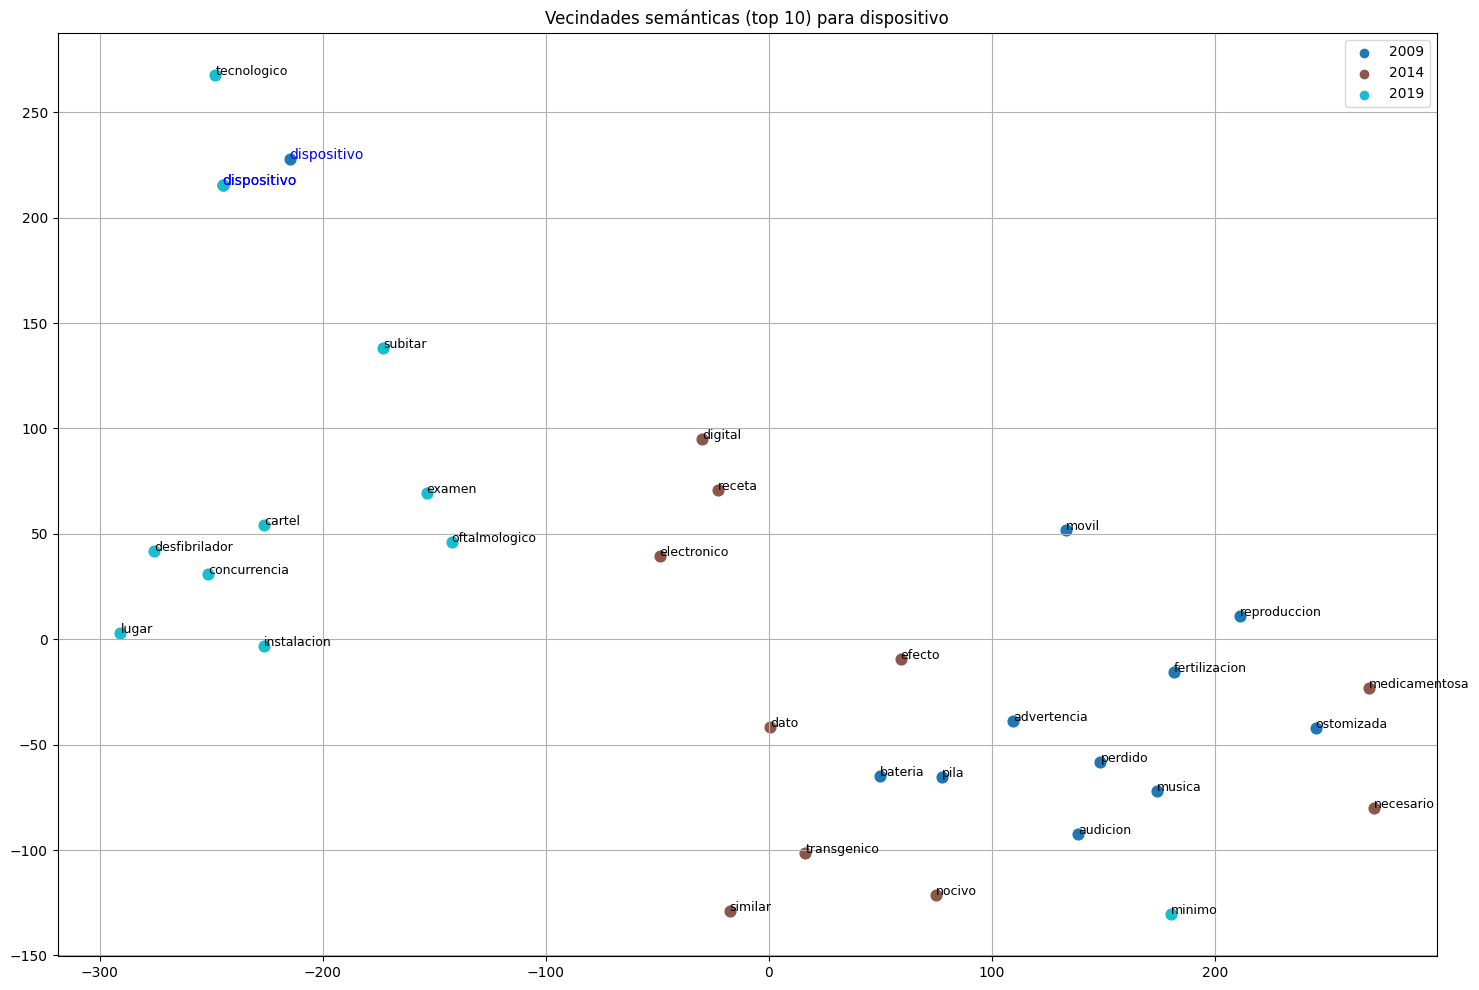

C:\Users\Usuario\AppData\Local\Temp\ipykernel_16544\1037429804.py:35: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  color_map = plt.cm.get_cmap("tab10", len(periods))


2009
[('digno', 0.8020732998847961), ('subitar', 0.7814271450042725), ('paliativo', 0.7793755531311035), ('judicial', 0.6994466185569763), ('historia', 0.6844351291656494), ('espacio', 0.6751762628555298), ('clinico', 0.6647226810455322), ('informado', 0.6604322791099548), ('digital', 0.6446006298065186), ('relacion', 0.6425409317016602)]
2014
[('subitar', 0.8354923725128174), ('digno', 0.7309185862541199), ('paliativo', 0.7275931239128113), ('natural', 0.6211504340171814), ('comision', 0.5836899280548096), ('escolar', 0.5635231733322144), ('desfibrilador', 0.5311853289604187), ('promover', 0.5257570147514343), ('cuidado', 0.5130002498626709), ('voluntario', 0.49573051929473877)]
2019
[('subitar', 0.7041171193122864), ('asistido', 0.5346629619598389), ('escolar', 0.5011634230613708), ('octubre', 0.5002235174179077), ('nacido', 0.4995713531970978), ('reproduccion', 0.48950228095054626), ('natural', 0.487937867641449), ('recien', 0.48673099279403687), ('digno', 0.48129233717918396), ('co

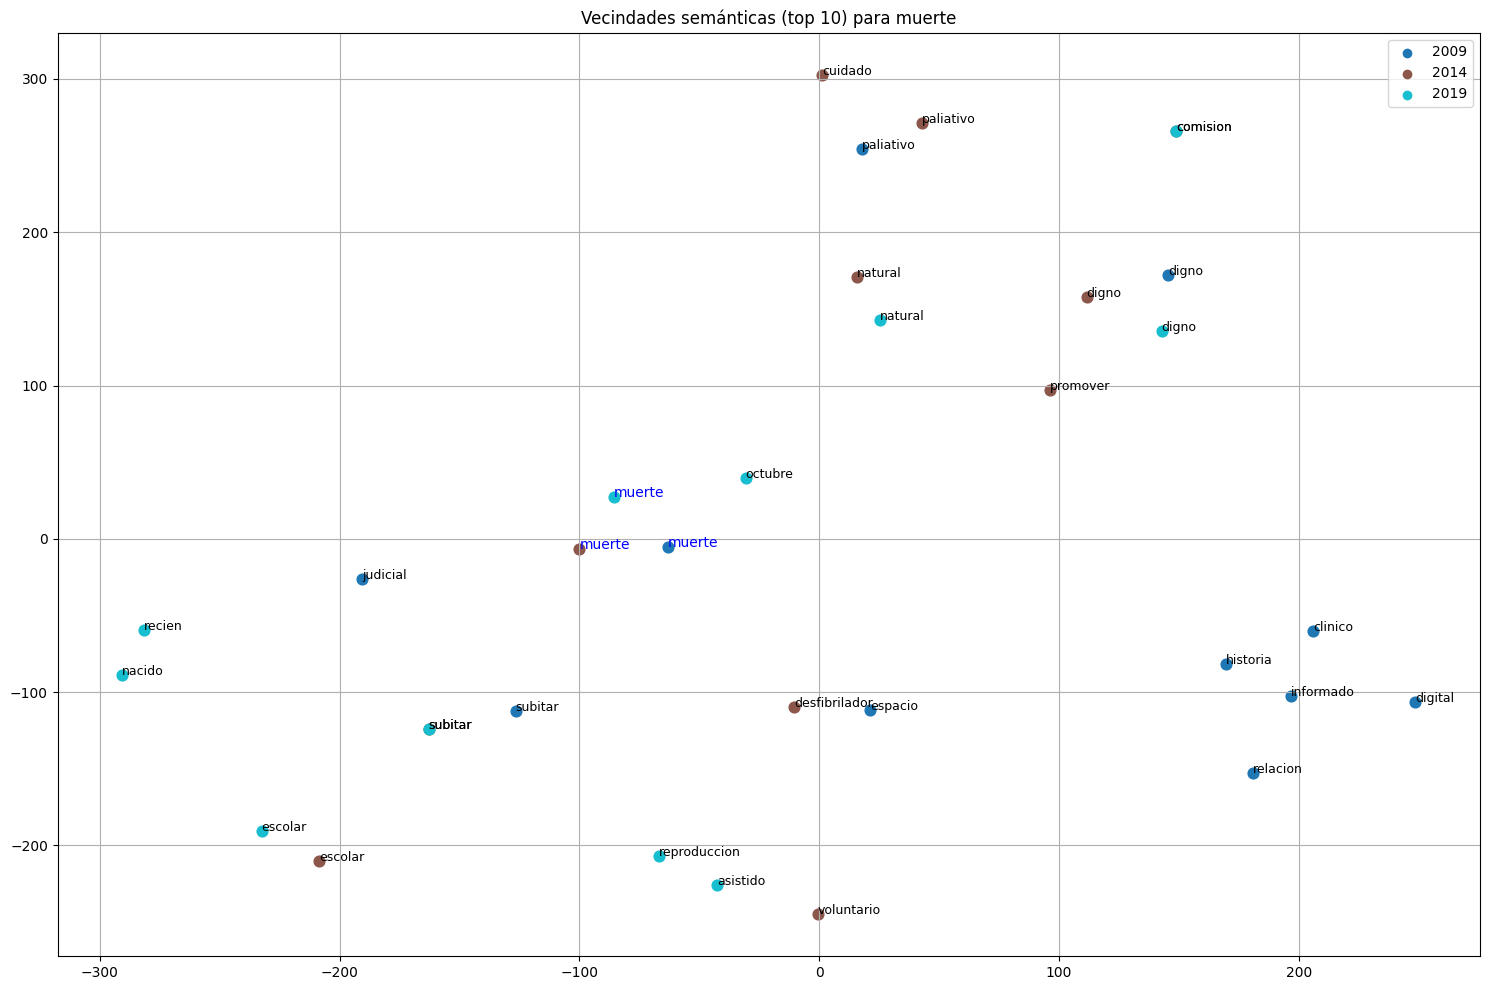

C:\Users\Usuario\AppData\Local\Temp\ipykernel_16544\1037429804.py:35: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  color_map = plt.cm.get_cmap("tab10", len(periods))


2009
[('mistanasica', 0.8318275809288025), ('consultoria', 0.8198516368865967), ('puerperio', 0.7426341772079468), ('embarazo', 0.6751314401626587), ('parto', 0.6583433747291565), ('enfermo', 0.6569724678993225), ('embarazado', 0.6367679834365845), ('bullos', 0.6286981701850891), ('ciudadano', 0.6228841543197632), ('epidermolisis', 0.6163883805274963)]
2014
[('caso', 0.6734517812728882), ('calidad', 0.656887948513031), ('fibromialgia', 0.6208325028419495), ('paliativo', 0.6021857261657715), ('familia', 0.6017916202545166), ('digno', 0.5824854969978333), ('voluntario', 0.5803477764129639), ('acv', 0.5589386820793152), ('accidente', 0.5412355065345764), ('congenita', 0.5392532348632812)]
2019
[('geriatrico', 0.6121549606323242), ('embarazado', 0.5880488753318787), ('paliativo', 0.5702536106109619), ('encontrar', 0.5600765347480774), ('establecido', 0.5331965684890747), ('comite', 0.5083640217781067), ('politica', 0.5013307332992554), ('accidente', 0.4736791253089905), ('cuidado', 0.46365

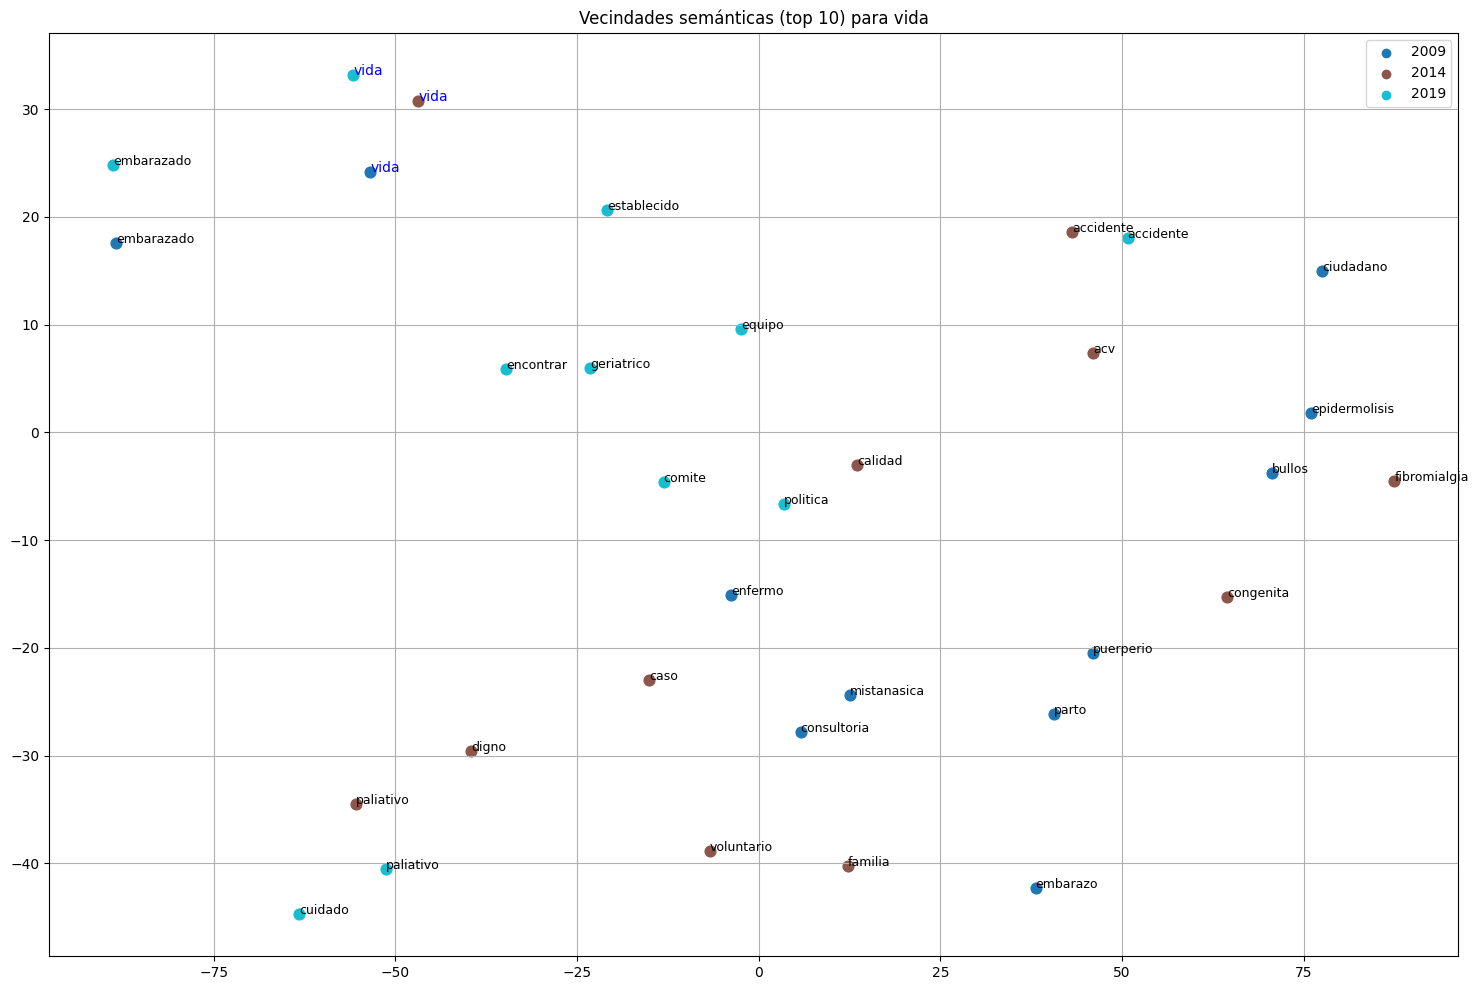

C:\Users\Usuario\AppData\Local\Temp\ipykernel_16544\1037429804.py:35: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  color_map = plt.cm.get_cmap("tab10", len(periods))


 'vivir' no está en el vocabulario del período 2009
 'vivir' no está en el vocabulario del período 2014
 'vivir' no está en el vocabulario del período 2019
No hay datos suficientes para graficar.
 'morir' no está en el vocabulario del período 2009
 'morir' no está en el vocabulario del período 2014
 'morir' no está en el vocabulario del período 2019
No hay datos suficientes para graficar.
 'capacitarcion' no está en el vocabulario del período 2009
 'capacitarcion' no está en el vocabulario del período 2014
 'capacitarcion' no está en el vocabulario del período 2019
No hay datos suficientes para graficar.
 'capacitar' no está en el vocabulario del período 2009
 'capacitar' no está en el vocabulario del período 2014
 'capacitar' no está en el vocabulario del período 2019
No hay datos suficientes para graficar.
 'capacita' no está en el vocabulario del período 2009
 'capacita' no está en el vocabulario del período 2014
 'capacita' no está en el vocabulario del período 2019
No hay datos su

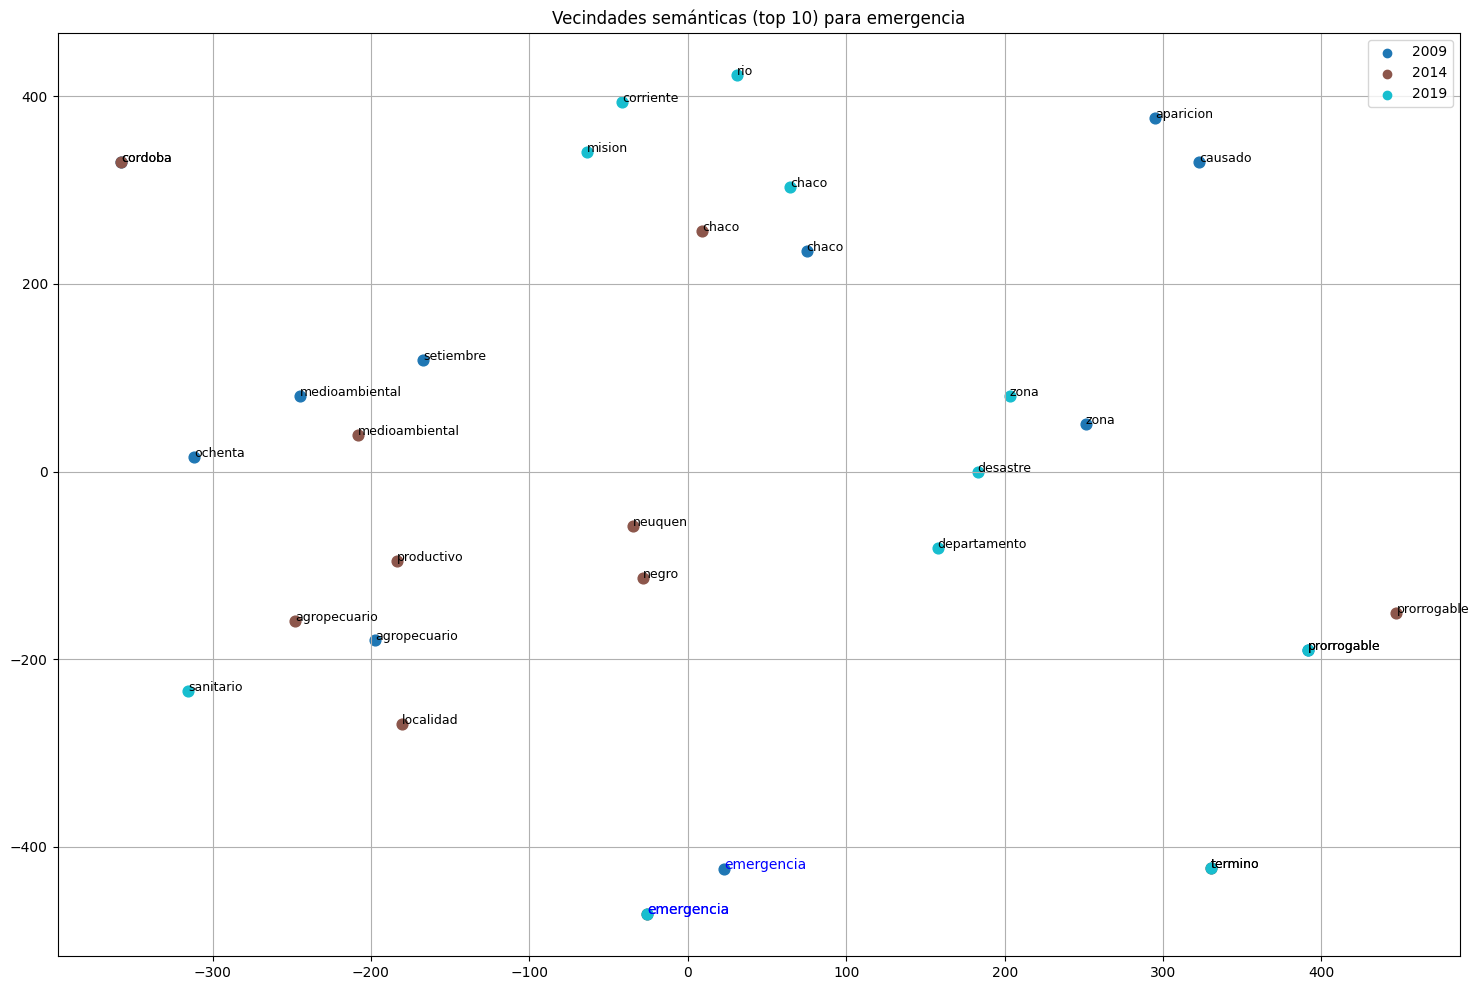

C:\Users\Usuario\AppData\Local\Temp\ipykernel_16544\1037429804.py:35: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  color_map = plt.cm.get_cmap("tab10", len(periods))


 'supervivencia' no está en el vocabulario del período 2009
 'supervivencia' no está en el vocabulario del período 2014
 'supervivencia' no está en el vocabulario del período 2019
No hay datos suficientes para graficar.
 'reanimacion' no está en el vocabulario del período 2009
 'reanimacion' no está en el vocabulario del período 2014
 'reanimacion' no está en el vocabulario del período 2019
No hay datos suficientes para graficar.
2009
[('accidente', 0.4919305741786957), ('delito', 0.4719984233379364), ('cerebrovascular', 0.4671279788017273), ('transmisibl', 0.46411532163619995), ('accion', 0.4605696201324463), ('acv', 0.459772527217865), ('seguimiento', 0.45302608609199524), ('acvo', 0.4520121216773987), ('manejo', 0.4444478154182434), ('politica', 0.4444161057472229)]
2014
[('dengue', 0.4610193371772766), ('cerebrovascular', 0.4544680714607239), ('acv', 0.44102951884269714), ('acvo', 0.4354182183742523), ('accidente', 0.42349207401275635), ('comite', 0.407539427280426), ('exposicion',

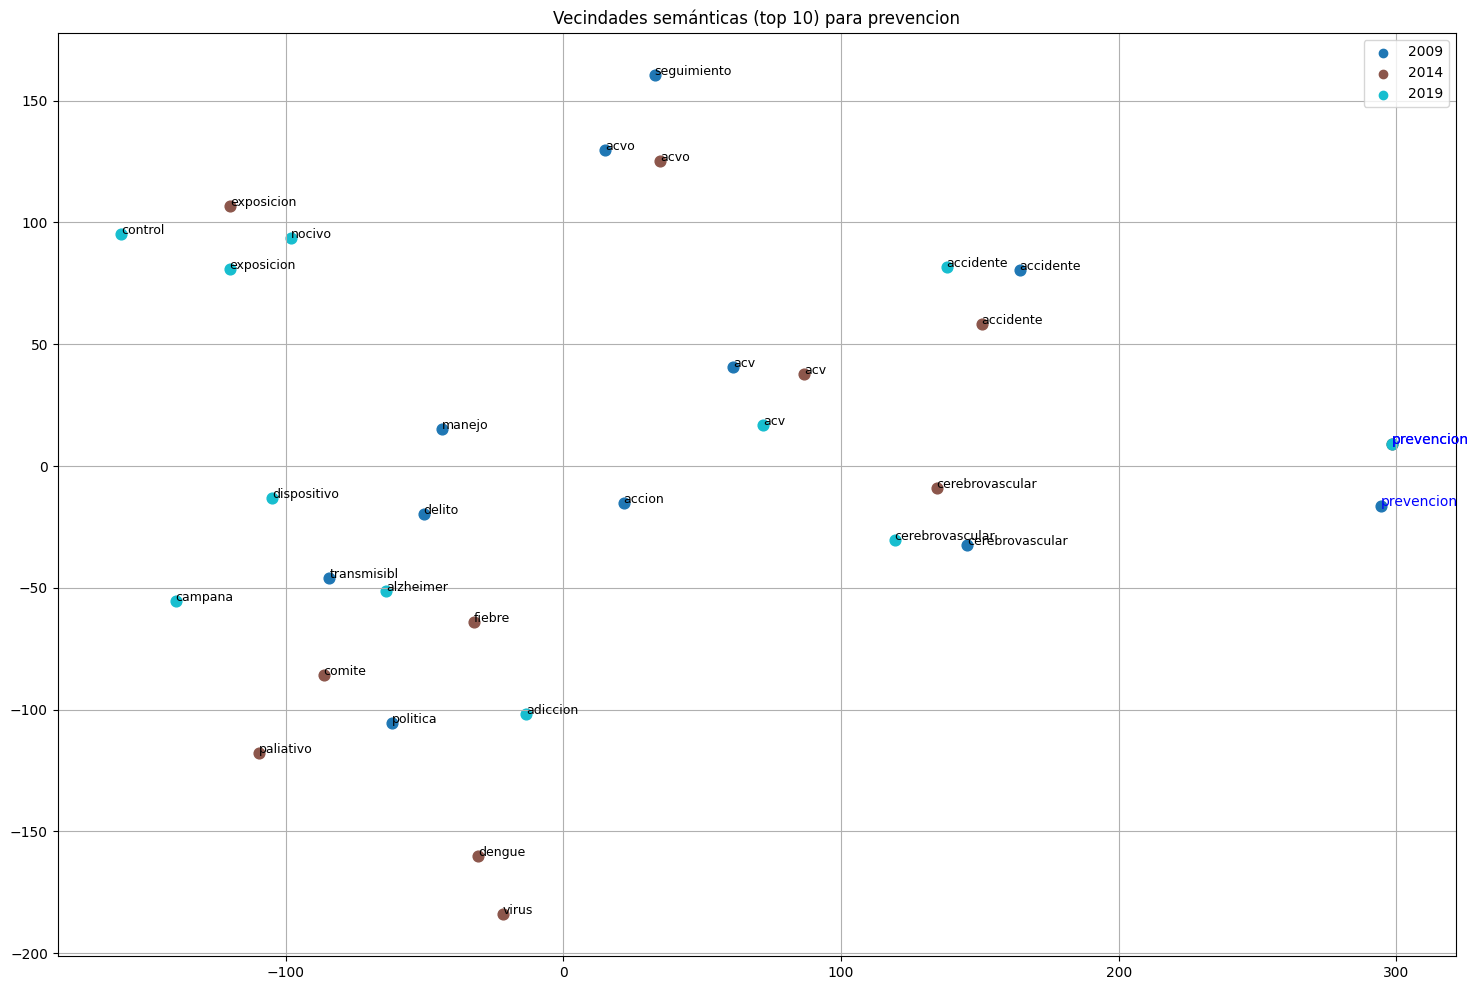

 'incidencia' no está en el vocabulario del período 2009
 'incidencia' no está en el vocabulario del período 2014
 'incidencia' no está en el vocabulario del período 2019
No hay datos suficientes para graficar.


C:\Users\Usuario\AppData\Local\Temp\ipykernel_16544\1037429804.py:35: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  color_map = plt.cm.get_cmap("tab10", len(periods))


In [20]:
for palabra in ms_palabras : 
    plot_neighbors_tsne(palabra, embeddings_by_period,alineados, [2009,2014,2019], top_k=10)


**Enfoque por el promedio de 50 iteraciones**

Se muestra las palabras más estables en la vecindad de la palabra analizada para cada periodo.

In [25]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.spatial.distance import cosine

def plot_neighbors_tsne2(palabra_objetivo, vectores_promedio_por_periodo, vecinos=10, perplexity=5, figsize=(15, 10)):
    """
    Visualiza con t-SNE el cambio semántico de una palabra y sus vecinos a través de períodos.

    Parameters:
    - palabra_objetivo: str, palabra a analizar
    - vectores_promedio_por_periodo: dict. Ej: {2019: {'palabra': vector, ...}, 2014: {...}, ...}
    - vecinos: int, cantidad de vecinos semánticos a mostrar por período
    - perplexity: int, parámetro de t-SNE
    - figsize: tuple, tamaño del gráfico
    """
    X = []
    labels = []
    colores = []

    for periodo, vectores in vectores_promedio_por_periodo.items():
        if palabra_objetivo not in vectores:
            continue

        # Vector de la palabra objetivo
        X.append(vectores[palabra_objetivo])
        labels.append(f'{palabra_objetivo}')
        colores.append(periodo)

        # Vecinos por similitud coseno
        vecinos_similares = sorted(
            vectores.items(),
            key=lambda kv: cosine(kv[1], vectores[palabra_objetivo])
        )[1:vecinos+1]

        for vecino, vec in vecinos_similares:
            X.append(vec)
            labels.append(f'{vecino}')
            colores.append(periodo)

    if not X:
        print(f' La palabra "{palabra_objetivo}" no se encuentra en ningún período.')
        return

    # t-SNE
    X = np.array(X)
    tsne = TSNE(n_components=2, random_state=42, perplexity=perplexity)
    X_2d = tsne.fit_transform(X)

    # Mapa de colores por período
    colores_unicos = sorted(set(colores))
    cmap = plt.cm.get_cmap('Set1', len(colores_unicos))
    periodo_color = {p: cmap(i) for i, p in enumerate(colores_unicos)}

    # Gráfico
    plt.figure(figsize=figsize)
    for i, label in enumerate(labels):
        x, y = X_2d[i]
        periodo = colores[i]
        plt.scatter(x, y, c=[periodo_color[periodo]], s=80 if label.startswith(palabra_objetivo) else 40)
        plt.text(x+0.2, y, label, fontsize=8)

    # Leyenda
    handles = [plt.Line2D([0], [0], marker='o', color='w', label=str(p),
                          markerfacecolor=periodo_color[p], markersize=10)
               for p in colores_unicos]

    plt.legend(handles=handles, title='Período')
    plt.title(f'Vecinos semánticos de "{palabra_objetivo}" por período (t-SNE)')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

C:\Users\Usuario\AppData\Local\Temp\ipykernel_16544\220321280.py:51: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('Set1', len(colores_unicos))


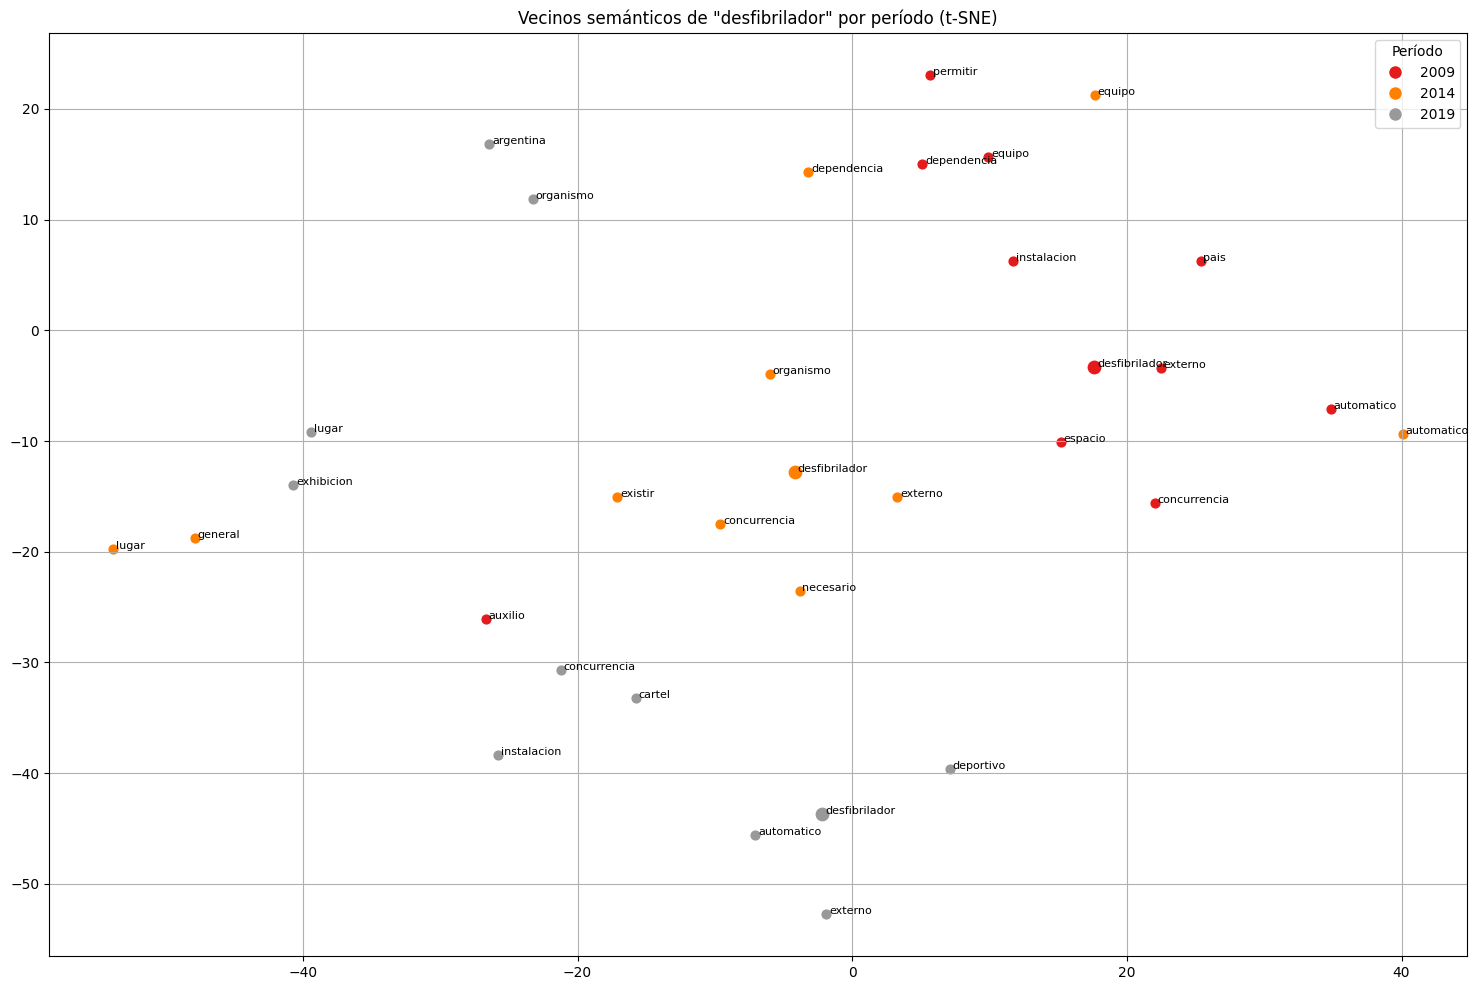

 La palabra "cardiopulmonar" no se encuentra en ningún período.
 La palabra "cardioasistido" no se encuentra en ningún período.
 La palabra "cardio" no se encuentra en ningún período.


C:\Users\Usuario\AppData\Local\Temp\ipykernel_16544\220321280.py:51: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('Set1', len(colores_unicos))


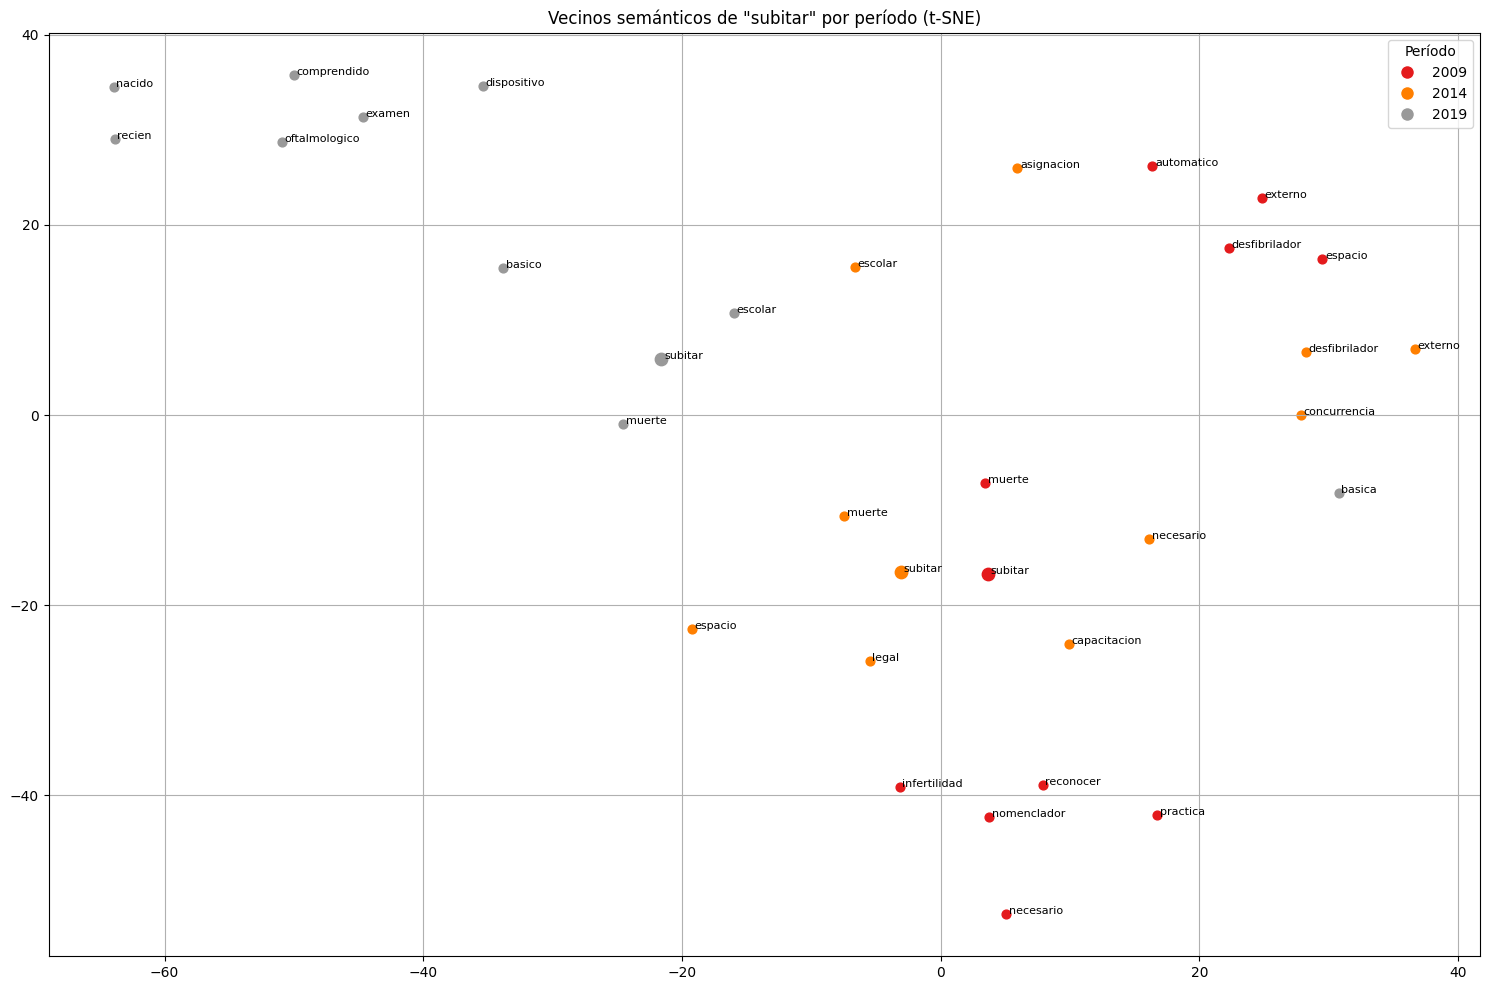

 La palabra "subita" no se encuentra en ningún período.
 La palabra "dea" no se encuentra en ningún período.


C:\Users\Usuario\AppData\Local\Temp\ipykernel_16544\220321280.py:51: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('Set1', len(colores_unicos))


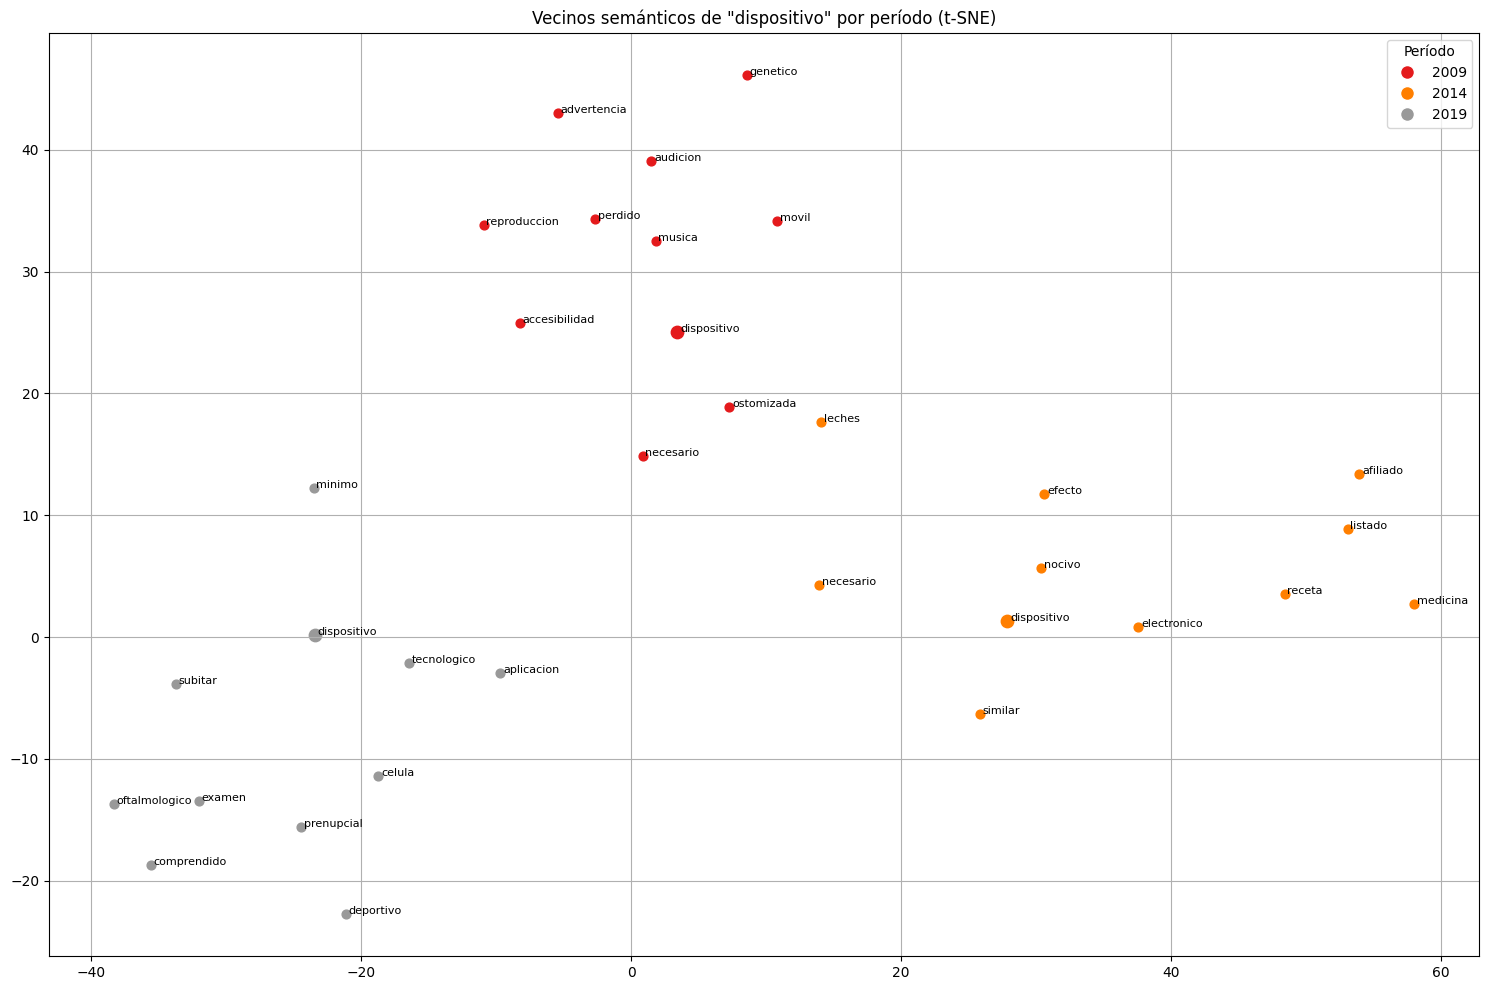

C:\Users\Usuario\AppData\Local\Temp\ipykernel_16544\220321280.py:51: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('Set1', len(colores_unicos))


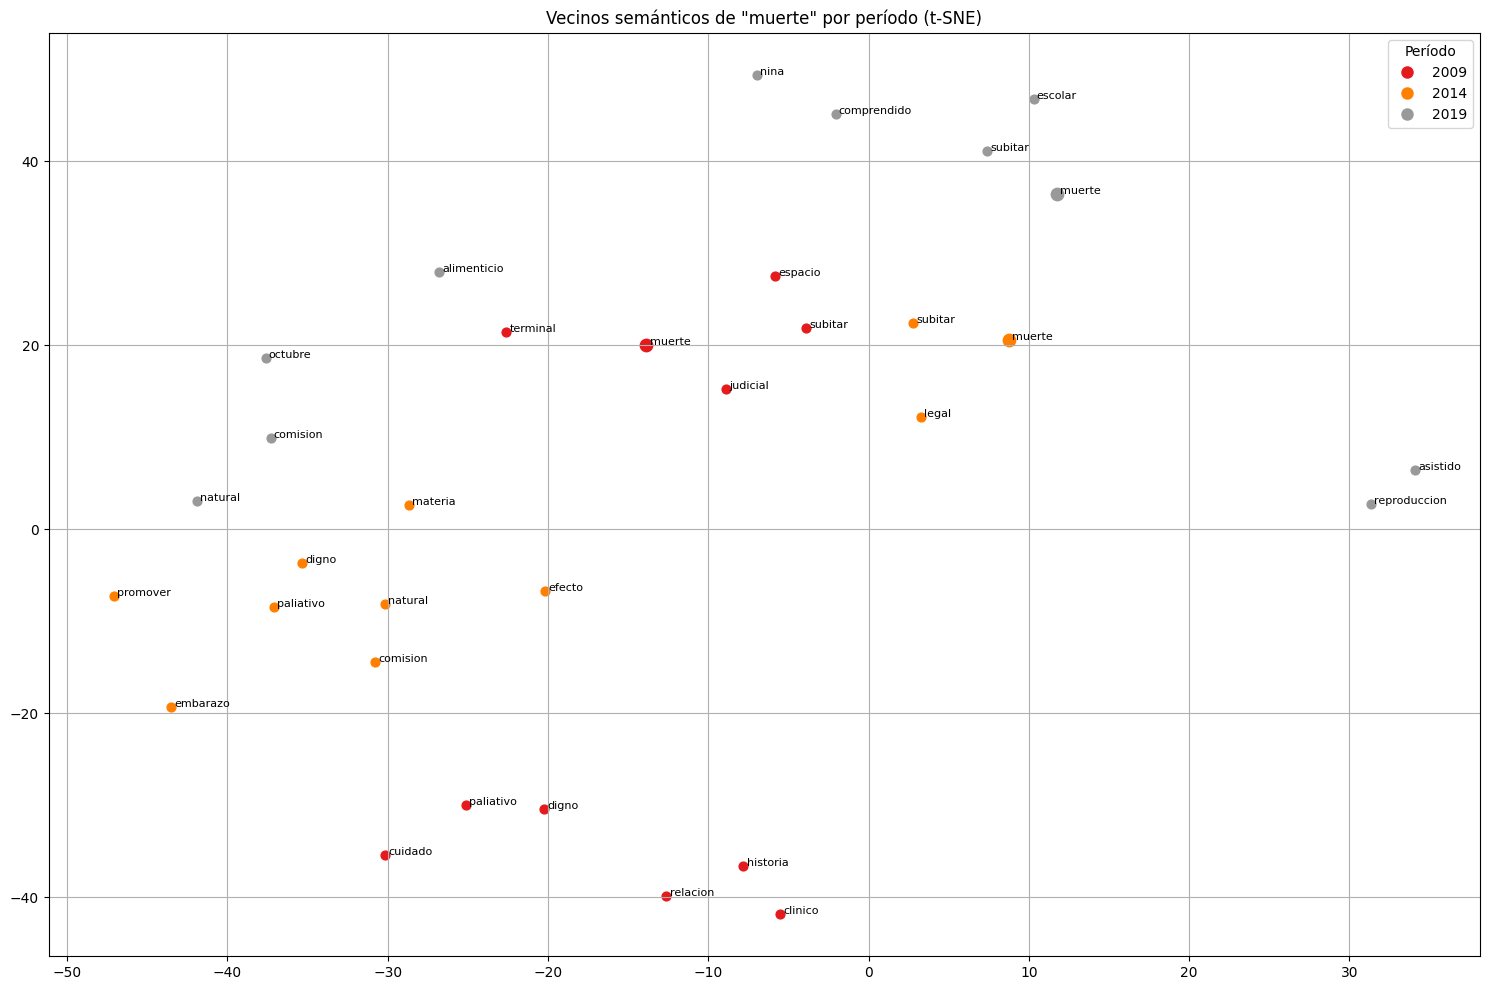

C:\Users\Usuario\AppData\Local\Temp\ipykernel_16544\220321280.py:51: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('Set1', len(colores_unicos))


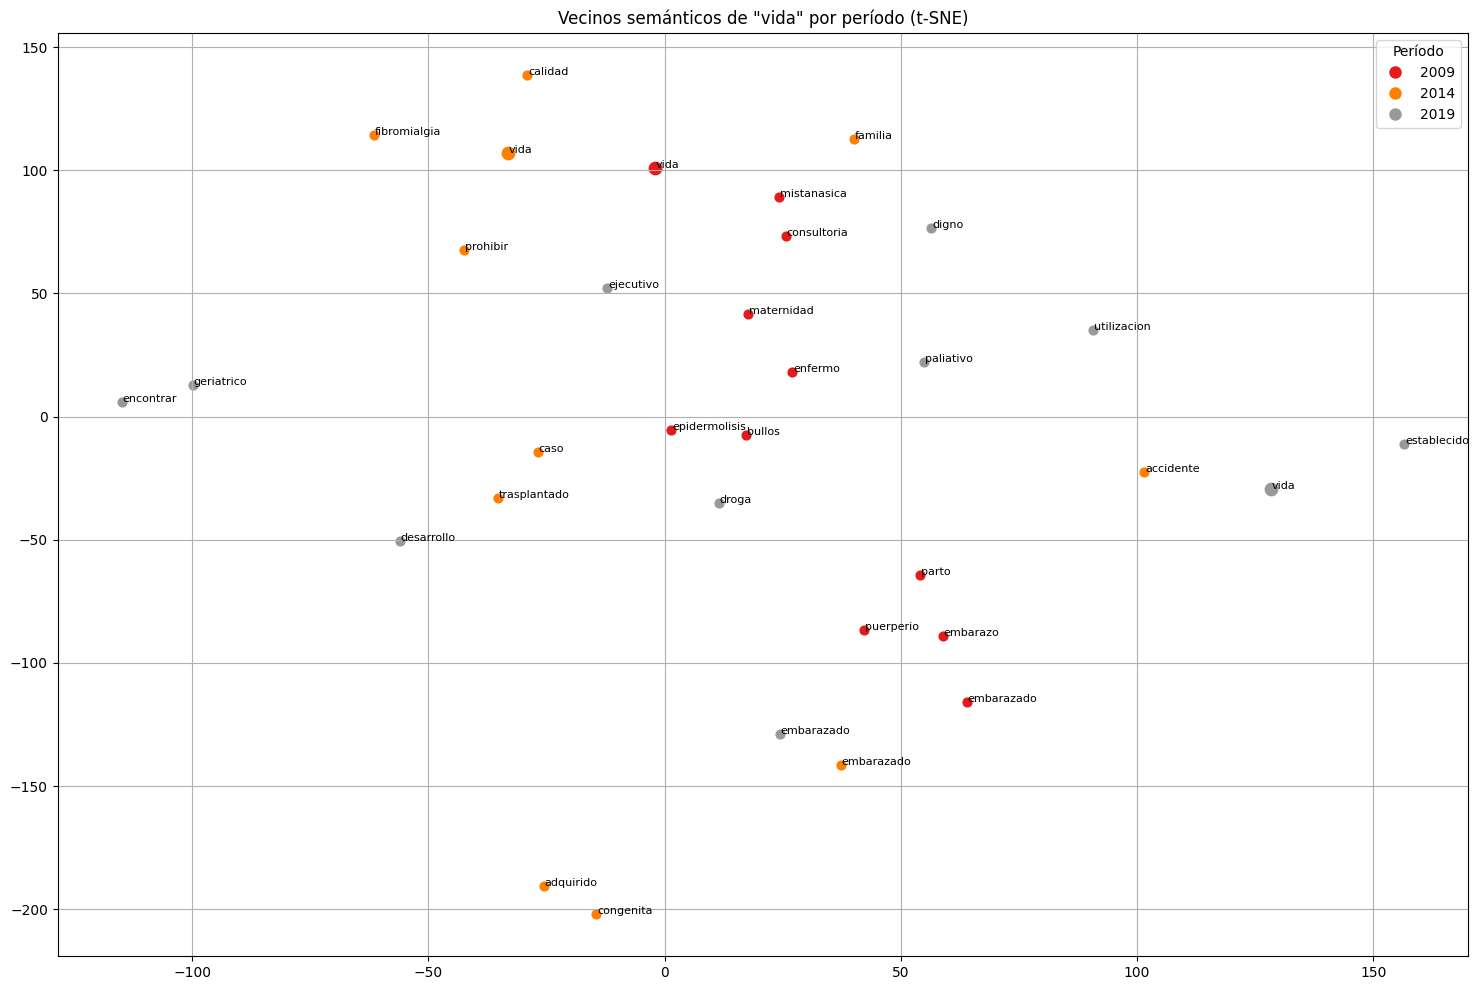

 La palabra "vivir" no se encuentra en ningún período.
 La palabra "morir" no se encuentra en ningún período.
 La palabra "capacitarcion" no se encuentra en ningún período.
 La palabra "capacitar" no se encuentra en ningún período.
 La palabra "capacita" no se encuentra en ningún período.


C:\Users\Usuario\AppData\Local\Temp\ipykernel_16544\220321280.py:51: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('Set1', len(colores_unicos))


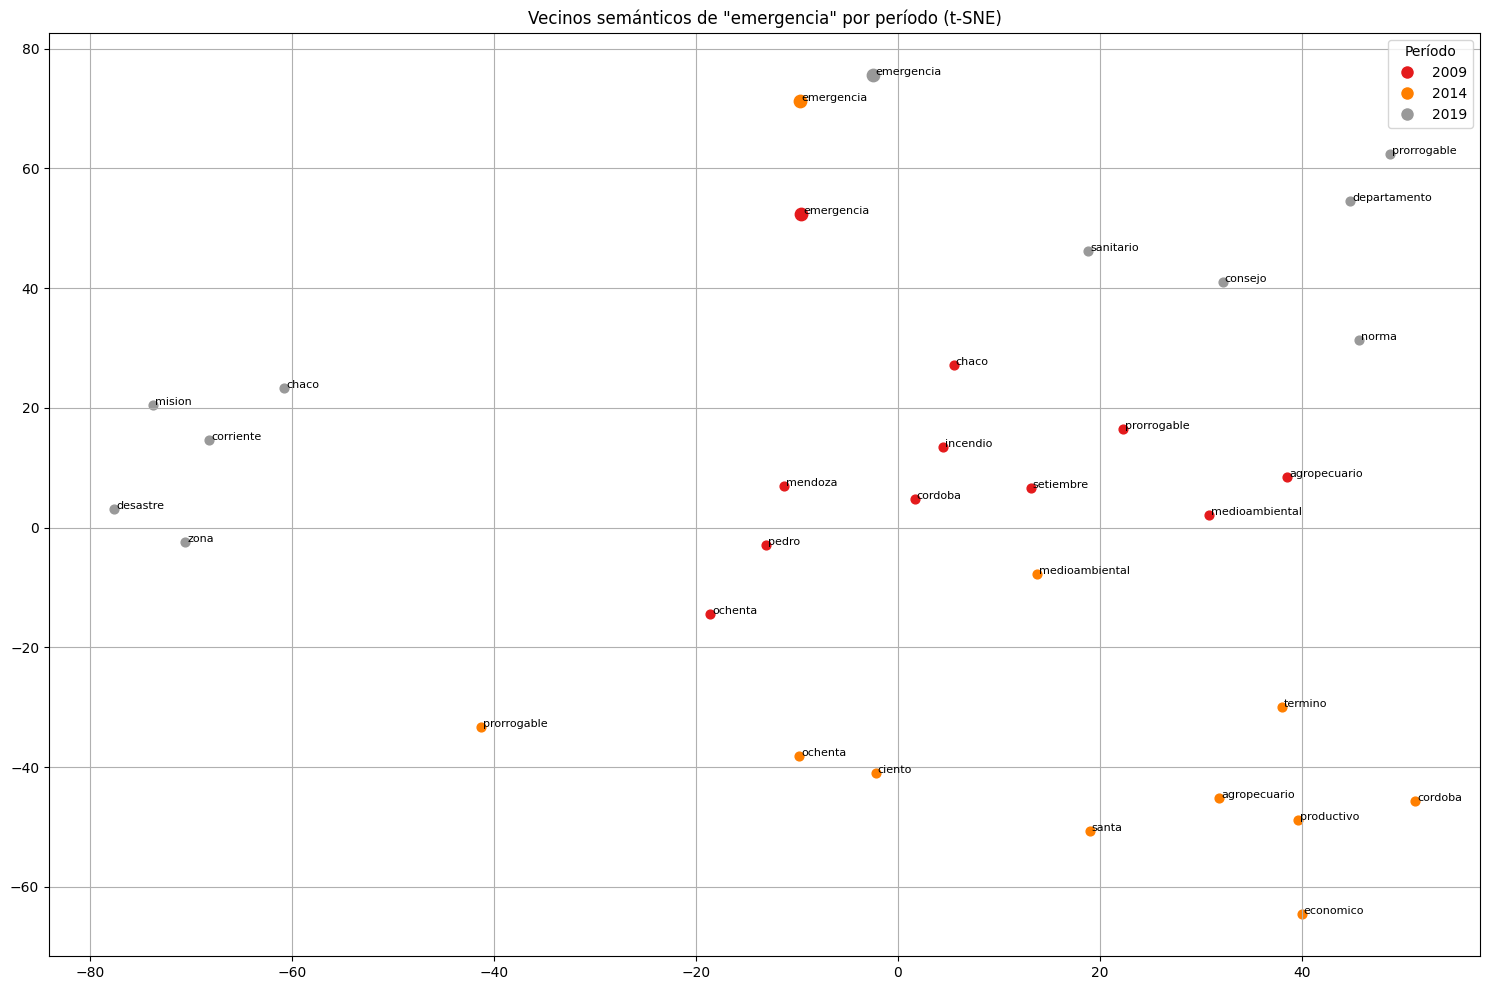

 La palabra "supervivencia" no se encuentra en ningún período.
 La palabra "reanimacion" no se encuentra en ningún período.


C:\Users\Usuario\AppData\Local\Temp\ipykernel_16544\220321280.py:51: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('Set1', len(colores_unicos))


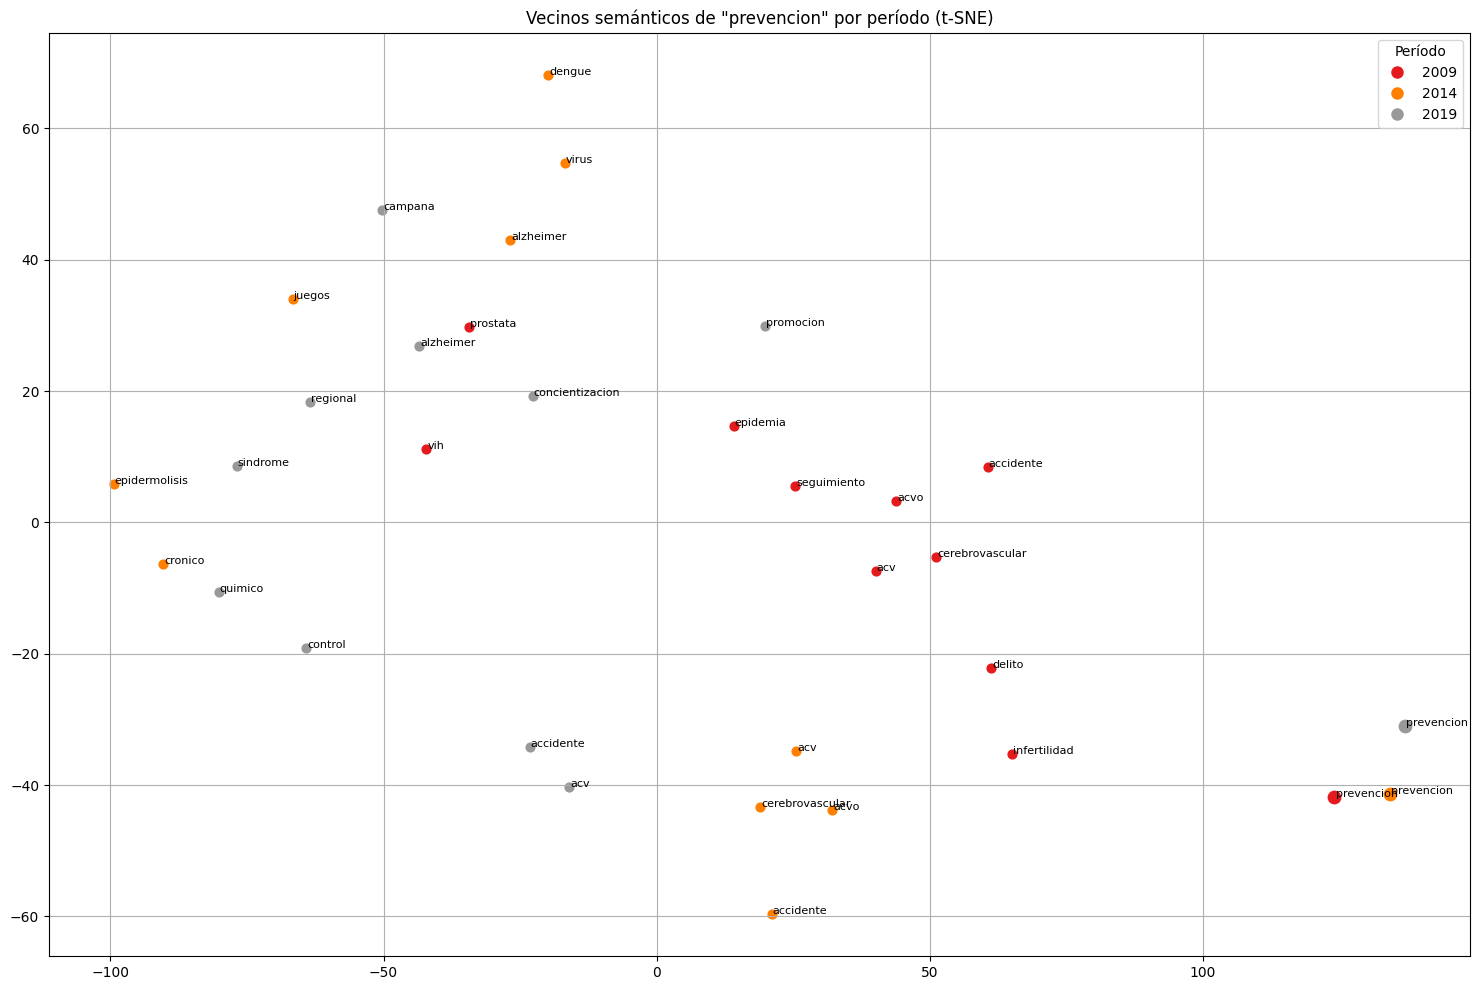

 La palabra "incidencia" no se encuentra en ningún período.


In [29]:
for palabra in ms_palabras : 
    plot_neighbors_tsne2(palabra, vectores_promedio, vecinos=10)


### Análisis de temporalidad

¿Cuándo se usan más las palabras en los títulos de iniciativas legislativas de ley sobre salud
?
* La cantidad de proyectos asociados a las palabras vinculadas 'muerte súbita': 425
    * 14.92 %. Tener en cuenta que se incluyen a las palabras vinculadas "emergencia", "prevención", "vida", "muerte". Muy presentes por la pandamía.


In [30]:
# Abrir
with open(os.getenv("DIR_DATOS_PROCESADOS") + 'base_texto_df_ley_0924.pkl', 'rb') as file: 
    basetexto_df = pickle.load(file)

basetexto_df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Proyecto.ID,35179,35179,HCDN246858,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Título,35179,33168,JUICIO POR JURADOS. CREACION.,18,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Título procesado,35179,29558,contrato de trabajo ley numero modificacion del articulo numero sobre licencias especiales,36,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Título normalizado,35179,28761,licencia especial,39,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Cant_token,35179.0,NaN,NaN,NaN,21.123682,10.69187,2.0,14.0,19.0,27.0,125.0
Cant_token_normalizado,35179.0,NaN,NaN,NaN,9.76341,5.051387,0.0,6.0,9.0,12.0,57.0
Proyecto_girado_a_comisiones_SALUD,35179.0,NaN,NaN,NaN,0.12786,0.333939,0.0,0.0,0.0,0.0,1.0
Proyecto_SALUD,35179.0,NaN,NaN,NaN,0.085761,0.280015,0.0,0.0,0.0,0.0,1.0
Resultado,35179,6,NO TUVO TRATAMIENTO POSTERIOR NI DICTAMEN,34268,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Max_Orden,35179.0,NaN,NaN,NaN,2.253504,0.822105,1.0,2.0,2.0,3.0,8.0


In [31]:
# Seleccionando IL de Salud
basetexto_df = basetexto_df[basetexto_df['Proyecto_SALUD']==1]
print("Conj. de datos de proyecto_SALUD con Nan en Período:",basetexto_df.shape)
basetexto_df = basetexto_df[~basetexto_df['Periodo'].isna()]
print("Conj. de datos de proyecto_SALUD sin Nan en Período:",basetexto_df.shape)

Conj. de datos de proyecto_SALUD con Nan en Período: (3017, 14)
Conj. de datos de proyecto_SALUD sin Nan en Período: (2848, 14)


In [32]:
basetexto_df.head(1)

,Proyecto.ID,Título,Título procesado,Título normalizado,Cant_token,Cant_token_normalizado,Proyecto_girado_a_comisiones_SALUD,Proyecto_SALUD,Resultado,Max_Orden,Tiene_antecedente_por_titulo_proy,Periodo,Año,Tokens
2061,HCDN272685,INCLUYASE EN EL CALENDARIO NACIONAL DE VACUNACION CON CARACTER OBLIGATORIO Y GRATUITO LA VACUNA CONTRA EL VIRUS DEL DENGUE. MODIFICACION DE LA LEY 27491.,incluyase en el calendario nacional de vacunacion con caracter obligatorio y gratuito la vacuna contra el virus del dengue modificacion de la ley numero,incluyar calendario nacional vacunacion caracter obligatorio gratuito vacuna virus dengue,24,10,1.0,1.0,NO TUVO TRATAMIENTO POSTERIOR NI DICTAMEN,3,False,141.0,2024,"[incluyar, calendario, nacional, vacunacion, caracter, obligatorio, gratuito, vacuna, virus, dengue]"


In [33]:
basetexto_df.columns

Index(['Proyecto.ID', 'Título', 'Título procesado', 'Título normalizado',
       'Cant_token', 'Cant_token_normalizado',
       'Proyecto_girado_a_comisiones_SALUD', 'Proyecto_SALUD', 'Resultado',
       'Max_Orden', 'Tiene_antecedente_por_titulo_proy', 'Periodo', 'Año',
       'Tokens'],
      dtype='object')

In [34]:
import pandas as pd
from collections import Counter
import matplotlib.pyplot as plt
import matplotlib.cm as cm

In [35]:
ms_palabras

['desfibrilador',
 'cardiopulmonar',
 'cardioasistido',
 'cardio',
 'subitar',
 'subita',
 'dea',
 'dispositivo',
 'muerte',
 'vida',
 'vivir',
 'morir',
 'capacitarcion',
 'capacitar',
 'capacita',
 'emergencia',
 'supervivencia',
 'reanimacion',
 'prevencion',
 'incidencia']

In [36]:
# Convertimos a minúscula y verificamos si la palabra aparece en el título
for palabra in ms_palabras:
    basetexto_df[palabra] = basetexto_df['Título normalizado'].str.contains(rf'\b{palabra}\b', case=False)

In [37]:
basetexto_df.head(2)

,Proyecto.ID,Título,Título procesado,Título normalizado,Cant_token,Cant_token_normalizado,Proyecto_girado_a_comisiones_SALUD,Proyecto_SALUD,Resultado,Max_Orden,...,vivir,morir,capacitarcion,capacitar,capacita,emergencia,supervivencia,reanimacion,prevencion,incidencia
2061,HCDN272685,INCLUYASE EN EL CALENDARIO NACIONAL DE VACUNACION CON CARACTER OBLIGATORIO Y GRATUITO LA VACUNA CONTRA EL VIRUS DEL DENGUE. MODIFICACION DE LA LEY 27491.,incluyase en el calendario nacional de vacunacion con caracter obligatorio y gratuito la vacuna contra el virus del dengue modificacion de la ley numero,incluyar calendario nacional vacunacion caracter obligatorio gratuito vacuna virus dengue,24,10,1.0,1.0,NO TUVO TRATAMIENTO POSTERIOR NI DICTAMEN,3,...,False,False,False,False,False,False,False,False,False,False
2067,HCDN272690,INCLUIR EN EL CALENDARIO NACIONAL DE VACUNACION CON CARACTER OBLIGATORIO Y GRATUITO LA VACUNA CONTRA EL VIRUS DEL DENGUE.,incluir en el calendario nacional de vacunacion con caracter obligatorio y gratuito la vacuna contra el virus del dengue,incluir calendario nacional vacunacion caracter obligatorio gratuito vacuna virus dengue,19,10,1.0,1.0,NO TUVO TRATAMIENTO POSTERIOR NI DICTAMEN,2,...,False,False,False,False,False,False,False,False,False,False


In [38]:
basetexto_df[['Proyecto.ID','desfibrilador', 'cardiopulmonar', 'cardioasistido', 'cardio',
       'subitar', 'subita', 'dea', 'dispositivo', 'emergencia',
       'supervivencia', 'reanimacion', 'prevencion']].shape #.groupby(['Proyecto.ID']).sum()

(2848, 13)

In [ ]:
#columnas_palabras = ['desfibrilador', 'cardiopulmonar', 'cardioasistido', 'cardio',
#       'subitar', 'subita', 'dea', 'dispositivo', 'emergencia',
#       'supervivencia', 'reanimacion', 'prevencion']

#ms_palabras = ['desfibrilador','subitar','dispositivo', 'muerte','vida','emergencia','prevencion']


In [41]:
proyectos_relevantes = basetexto_df[basetexto_df[ms_palabras].any(axis=1)]
print("Cantidad de proyectos asociados a las palabras vinculadas 'muerte súbita':" ,proyectos_relevantes.shape[0])
print("% :" , round((proyectos_relevantes.shape[0]/basetexto_df.shape[0]) * 100,2))


Cantidad de proyectos asociados a las palabras vinculadas 'muerte súbita': 478
% : 16.78


In [42]:
basetexto_df.columns

Index(['Proyecto.ID', 'Título', 'Título procesado', 'Título normalizado',
       'Cant_token', 'Cant_token_normalizado',
       'Proyecto_girado_a_comisiones_SALUD', 'Proyecto_SALUD', 'Resultado',
       'Max_Orden', 'Tiene_antecedente_por_titulo_proy', 'Periodo', 'Año',
       'Tokens', 'desfibrilador', 'cardiopulmonar', 'cardioasistido', 'cardio',
       'subitar', 'subita', 'dea', 'dispositivo', 'muerte', 'vida', 'vivir',
       'morir', 'capacitarcion', 'capacitar', 'capacita', 'emergencia',
       'supervivencia', 'reanimacion', 'prevencion', 'incidencia'],
      dtype='object')

In [44]:
frecuencias_df = basetexto_df[['Año',
       'desfibrilador', 'cardiopulmonar', 'cardioasistido', 'cardio',
       'subitar', 'subita', 'dea', 'dispositivo', 'muerte', 'vida', 'vivir',
       'morir', 'capacitarcion', 'capacitar', 'capacita', 'emergencia',
       'supervivencia', 'reanimacion', 'prevencion', 'incidencia']].groupby(['Año']).sum().T#reset_index()
frecuencias_df['total'] = frecuencias_df.sum(axis=1) 
frecuencias_df = frecuencias_df.sort_values('total', ascending=True).drop(columns='total')
frecuencias_df

Año,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
cardioasistido,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
subita,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
supervivencia,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
capacita,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
capacitarcion,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
capacitar,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
vivir,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0
cardio,0,0,0,0,0,0,1,0,0,0,1,0,1,0,0,0
morir,0,0,0,0,0,0,0,0,0,0,0,0,1,2,0,0
incidencia,0,0,0,0,0,0,1,0,0,2,0,1,0,0,0,0


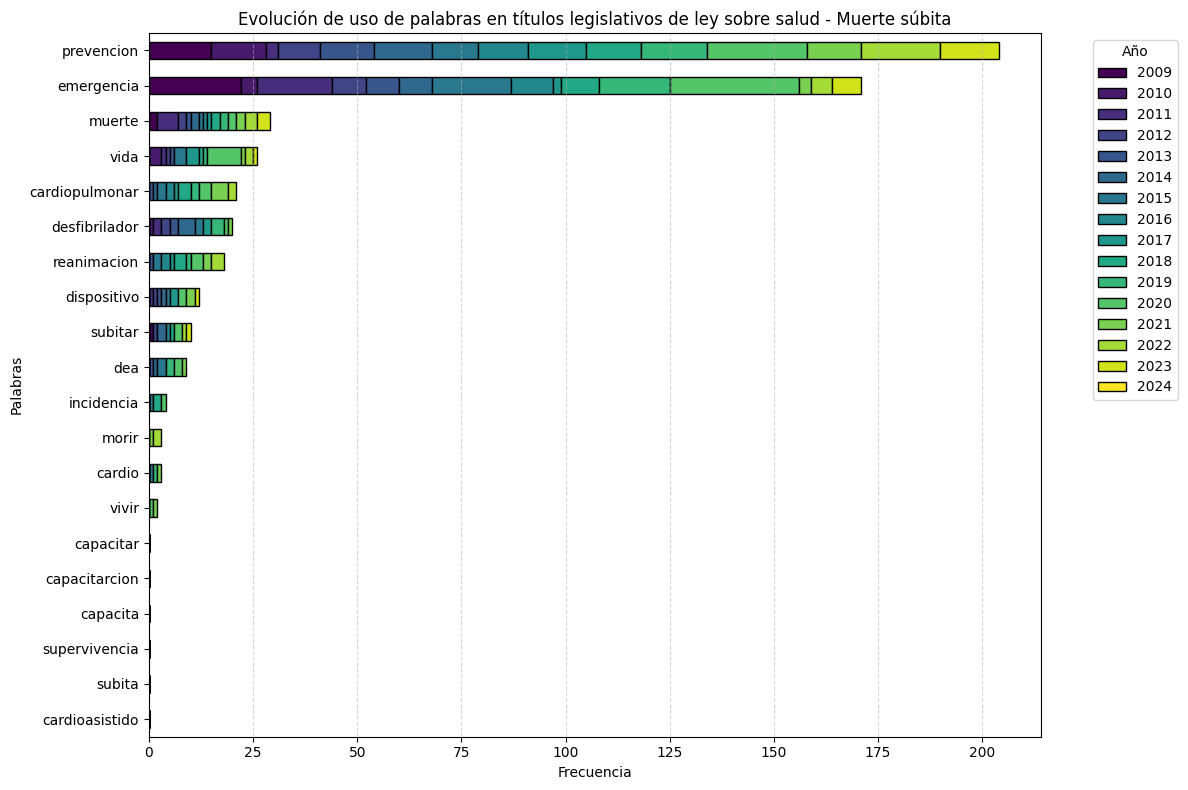

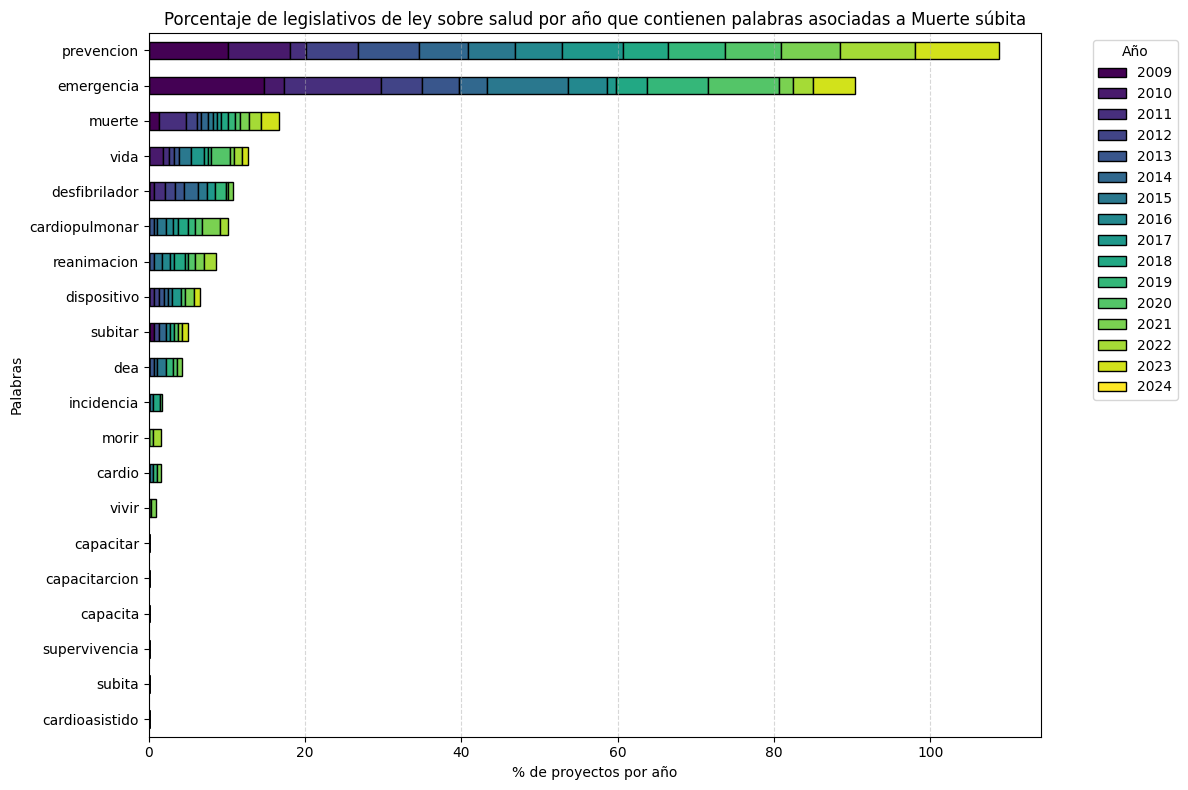

In [45]:
   
    frecuencias_df.plot(kind='barh',
                       stacked=True,
                       figsize=(12, 8),
                       colormap='viridis',  
                       edgecolor='black')
    
    plt.title('Evolución de uso de palabras en títulos legislativos de ley sobre salud - Muerte súbita')
    plt.xlabel('Frecuencia')
    plt.ylabel('Palabras' )
    plt.legend(title='Año', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.grid(axis='x', linestyle='--', alpha=0.5)
    plt.show()
    
    
    # Cantidad de proyectos por año (para normalizar)
    total_proyectos_por_anio = basetexto_df.groupby('Año').size()
    # frecuencia_df tiene palabras como índice y años como columnas (frecuencia absoluta)
    frecuencia_relativa_df = frecuencias_df.div(total_proyectos_por_anio, axis=1) * 100  # multiplicamos por 100 para %
    # Ordenar por promedio total para ordenar mejor las barras
    frecuencia_relativa_df['Promedio'] = frecuencia_relativa_df.mean(axis=1)
    frecuencia_relativa_df = frecuencia_relativa_df.sort_values('Promedio', ascending=True).drop(columns='Promedio')
    frecuencia_relativa_df.plot(kind='barh',
                                stacked=True,
                                figsize=(12, 8),
                                colormap='viridis',
                                edgecolor='black')
    
    plt.title('Porcentaje de legislativos de ley sobre salud por año que contienen palabras asociadas a Muerte súbita')
    plt.xlabel('% de proyectos por año')
    plt.ylabel('Palabras')
    plt.legend(title='Año', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.grid(axis='x', linestyle='--', alpha=0.5)
    plt.show()






### Proyectos con palabras asociadas a muerte súbitas

In [46]:
def mostrar_ejemplos_contextuales_titulos(df, palabra, periodo, n=5):
    """
    Muestra ejemplos de títulos que contienen una palabra específica en un periodo.

    Args:
        df (pd.DataFrame): DataFrame con columnas 'titulo' (o la columna de títulos) y 'periodo'.
        palabra (str): La palabra para buscar en los títulos (insensible a mayúsculas/minúsculas).
        periodo (int): El periodo de interés.
        n (int): Número de ejemplos a mostrar.
    """
    df_periodo = df[df['Periodo_5anios'] == periodo]
    titulos_con_palabra = df_periodo[df_periodo['Título normalizado'].str.lower().str.contains(palabra.lower(), na=False)]

    if not titulos_con_palabra.empty:
        print(f"\nEjemplos de títulos conteniendo '{palabra}' en el periodo {periodo}:")
        display(titulos_con_palabra[['Título','Título normalizado']].head(n))
    
    else:
        print(f"No se encontraron títulos conteniendo '{palabra}' en el periodo {periodo}.")


In [47]:
proyectos_relevantes.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Proyecto.ID,478,478,HCDN182460,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Título,478,460,ATENCION A VICTIMAS DE DELITOS SEXUALES Y PREVENCION DE ENFERMEDADES: REGIMEN.,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Título procesado,478,433,cuidados paliativos para promover la muerte natural y digna creacion de la comision nacional de cuidados paliativos en el ambito del ministerio de salud de la nacion reproduccion del expediente numero d numero,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Título normalizado,478,428,cuidado paliativo promover muerte natural digno creacion comision nacional cuidado paliativo ambito ministerio salud nacion,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Cant_token,478.0,NaN,NaN,NaN,21.196653,9.341137,3.0,14.0,20.0,26.0,64.0
Cant_token_normalizado,478.0,NaN,NaN,NaN,11.014644,4.504574,3.0,8.0,11.0,13.0,33.0
Proyecto_girado_a_comisiones_SALUD,478.0,NaN,NaN,NaN,1.0,0.0,1.0,1.0,1.0,1.0,1.0
Proyecto_SALUD,478.0,NaN,NaN,NaN,1.0,0.0,1.0,1.0,1.0,1.0,1.0
Resultado,478,2,NO TUVO TRATAMIENTO POSTERIOR NI DICTAMEN,469,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Max_Orden,478.0,NaN,NaN,NaN,2.433054,0.73167,1.0,2.0,2.0,3.0,5.0


**Desfibrilador**

In [48]:
proyectos_relevantes.loc[proyectos_relevantes['desfibrilador']==True,['Proyecto.ID','Año','Título','Resultado'],].sort_values(by='Año', ascending = False)

,Proyecto.ID,Año,Título,Resultado
6157,HCDN254580,2021,OBLIGATORIEDAD DE DOTAR CON DESFIBRILADORES EXTERNOS AUTOMATICOS - DEA - EN ESPACIOS PUBLICOS Y PRIVADOS DE GRAN CONCURRENCIA.,NO TUVO TRATAMIENTO POSTERIOR NI DICTAMEN
10033,HCDN238616,2020,"ESTABLECESE LA OBLIGATORIEDAD DE CONTAR CON UN EQUIPO (DEA) DESFIBRILADOR EXTERNO AUTOMATICO, EN TODAS LAS AERONAVES QUE REALICEN OPERACIONES DE VUELOS .",NO TUVO TRATAMIENTO POSTERIOR NI DICTAMEN
10426,HCDN236949,2019,"INSTALACION DE ""DESFIBRILADORES EXTERNOS AUTOMATICOS - DEA -"", EN ESPACIOS PUBLICOS Y PRIVADOS.",NO TUVO TRATAMIENTO POSTERIOR NI DICTAMEN
10877,HCDN234971,2019,"OBLIGATORIEDAD DE INSTALAR EN TODOS LOS GIMNASIOS Y/O ESTABLECIMIENTOS DEPORTIVOS PUBLICOS Y PRIVADOS DE LA REPUBLICA ARGENTINA, DESFIBRILADORES EXTERNOS AUTOMATICOS (DEA).",NO TUVO TRATAMIENTO POSTERIOR NI DICTAMEN
11619,HCDN231335,2019,INSTALACION DE UN DESFIBRILADOR EXTERNO AUTOMATICO EN TODOS LOS LUGARES PUBLICOS Y PRIVADOS DE CONCURRENCIA MASIVA DE PERSONAS (REPRODUCCION DEL EXPEDIENTE 0125-D-17).,NO TUVO TRATAMIENTO POSTERIOR NI DICTAMEN
17224,HCDN196338,2017,DESFIBRILADORES. INSTALACION EN LAS AERONAVES DESTINADAS A VUELOS DE CABOTAJE.,NO TUVO TRATAMIENTO POSTERIOR NI DICTAMEN
17781,HCDN194929,2017,INSTALACION DE UN DESFIBRILADOR EXTERNO AUTOMATICO EN TODOS LOS LUGARES PUBLICOS Y PRIVADOS DE CONCURRENCIA MASIVA DE PERSONAS.,NO TUVO TRATAMIENTO POSTERIOR NI DICTAMEN
21419,HCDN175985,2015,INSTALACION DE UN DESFIBRILADOR EXTERNO AUTOMATICO EN TODOS LOS LUGARES PUBLICOS Y PRIVADOS EN LOS QUE EXISTA CONCURRENCIA MASIVA DE PERSONAS.,NO TUVO TRATAMIENTO POSTERIOR NI DICTAMEN
21887,HCDN174032,2015,GARANTIZAR LA DISPONIBILIDAD DE AL MENOS UN DESFIBRILADOR EXTERNO AUTOMATICO (DEA) EN TODAS LAS INSTITUCIONES DEPORTIVAS DEL PAIS,NO TUVO TRATAMIENTO POSTERIOR NI DICTAMEN
25105,HCDN160509,2014,DESFIBRILADORES EXTERNOS AUTOMATICOS: SE ESTABLECE LA INSTALACION EN ESPACIOS PUBLICOS CARDIOPROTEGIDOS O CARDIOSEGUROS.,NO TUVO TRATAMIENTO POSTERIOR NI DICTAMEN


**Subitar**

In [49]:
proyectos_relevantes.loc[proyectos_relevantes['subitar']==True,['Proyecto.ID','Año','Título','Resultado'],].sort_values(by='Año', ascending = False)

,Proyecto.ID,Año,Título,Resultado
3168,HCDN266842,2023,PROTECCION DEL EMBARAZO Y DEL RECIEN NACIDO - LEY 25929 - MUERTE SUBITA - SISTEMA DE PREVENCION INTEGRAL - LEY 27159 - MODIFICACIONES SOBRE INSTRUCCION BASICA EN RCP EN EL ESTADO NACIONAL Y PARA PROGENITORES DE NIÑOS RECIEN NACIDOS EN SITUACION DE RIESGO.,NO TUVO TRATAMIENTO POSTERIOR NI DICTAMEN
5898,HCDN255602,2022,PROGRAMA DE DIFUSION E INFORMACION A PADRES Y MIEMBROS DE LA COMUNIDAD ESCOLAR DESTINADO A PREVENIR LA MUERTE SUBITA. REGIMEN. CAPACITACION EN REANIMACION CARDIOPULMONAR.,NO TUVO TRATAMIENTO POSTERIOR NI DICTAMEN
8633,HCDN243571,2020,"MUERTE SUBITA. SISTEMA DE PREVENCION INTEGRAL - LEY 27159 -. MODIFICACIONES SOBRE LA COLOCACION DE DISPOSITIVOS DEA EN ESTABLECIMIENTOS EDUCATIVOS PUBLICOS Y PRIVADOS, ESTABLECIMIENTOS DEPORTIVOS, GIMNASIOS, CLUBES Y SERVICIOS DE ALOJAMIENTO CON SECTORES DEPORTIVOS .",NO TUVO TRATAMIENTO POSTERIOR NI DICTAMEN
10195,HCDN238109,2020,PROGRAMA DE DIFUSION E INFORMACION A PADRES Y MIEMBROS DE LA COMUNIDAD ESCOLAR DESTINADO A PREVENIR LA MUERTE SUBITA. REGIMEN. CAPACITACION EN REANIMACION CARDIOPULMONAR.,NO TUVO TRATAMIENTO POSTERIOR NI DICTAMEN
14084,HCDN215087,2018,PROGRAMA DE DIFUSION E INFORMACION A PADRES Y MIEMBROS DE LA COMUNIDAD ESCOLAR DESTINADO A PREVENIR LA MUERTE SUBITA. REGIMEN. CAPACITACION EN REANIMACION CARDIOPULMONAR.,NO TUVO TRATAMIENTO POSTERIOR NI DICTAMEN
19669,HCDN185534,2016,PROGRAMA DE PREVENCION DE MUERTE SUBITA EN NIÑOS EN EDAD ESCOLAR Y ADOLESCENTES. REGIMEN.,NO TUVO TRATAMIENTO POSTERIOR NI DICTAMEN
23892,HCDN165110,2014,"MUERTE SUBITA: SE INCORPORA AL ""PROGRAMA MEDICO OBLIGATORIO"" SU COBERTURA, TRATAMIENTO Y PRACTICAS MEDICAS NECESARIAS PARA SU DETECCION TEMPRANA Y PREVENCION.",NO TUVO TRATAMIENTO POSTERIOR NI DICTAMEN
25237,HCDN160273,2014,MUERTE SUBITA: REGIMEN PARA SU PREVENCION EN ESPACIOS PUBLICOS Y PRIVADOS DE ACCESO PUBLICO (REPRODUCCION DEL EXPEDIENTE 3926-D-12).,NO TUVO TRATAMIENTO POSTERIOR NI DICTAMEN
28362,HCDN138128,2012,MUERTE SUBITA: REGIMEN PARA SU PREVENCION EN ESPACIOS PUBLICOS Y PRIVADOS DE ACCESO PUBLICO.,NO TUVO TRATAMIENTO POSTERIOR NI DICTAMEN
33533,HCDN110898,2009,"MUERTE SUBITA: INCORPORAR AL PROGRAMA MEDICO OBLIGATORIO SU COBERTURA, TRATAMIENTO Y PRACTICAS MEDICAS NECESARIAS PARA SU DETECCION TEMPRANA Y PREVENCION.",NO TUVO TRATAMIENTO POSTERIOR NI DICTAMEN


**Dispositivo**

In [50]:
proyectos_relevantes.loc[proyectos_relevantes['dispositivo']==True,['Proyecto.ID','Año','Título','Resultado'],].sort_values(by='Año', ascending = False)

,Proyecto.ID,Año,Título,Resultado
3470,HCDN266155,2023,"CONCIENTIZACION EN SALUD MENTAL Y PREVENCION DEL SUICIDIO. PLATAFORMA ""ESTAR"". CREACION DE UNA APLICACION GRATUITA PARA TELEFONOS CELULARES Y DISPOSITIVOS TECNOLOGICOS.",NO TUVO TRATAMIENTO POSTERIOR NI DICTAMEN
7259,HCDN249413,2021,"CONCIENTIZACION EN SALUD MENTAL Y PREVENCION DEL SUICIDIO. PLATAFORMA ""ESTAR"". CREACION DE UNA APLICACION GRATUITA PARA TELEFONOS CELULARES Y DISPOSITIVOS TECNOLOGICOS.",NO TUVO TRATAMIENTO POSTERIOR NI DICTAMEN
7741,HCDN247699,2021,INSTALACION OBLIGATORIA DE DISPOSITIVOS DE DETECCION DE EMISIONES DE MONOXIDO DE CARBONO.,NO TUVO TRATAMIENTO POSTERIOR NI DICTAMEN
8370,HCDN244725,2020,"ESTANDARES MINIMOS DE CALIDAD INSTITUCIONAL PARA DISPOSITIVOS RESIDENCIALES Y FAMILIARES DE CUIDADO PARA NIÑOS, NIÑAS Y ADOLESCENTES SIN CUIDADOS PARENTALES.",NO TUVO TRATAMIENTO POSTERIOR NI DICTAMEN
8633,HCDN243571,2020,"MUERTE SUBITA. SISTEMA DE PREVENCION INTEGRAL - LEY 27159 -. MODIFICACIONES SOBRE LA COLOCACION DE DISPOSITIVOS DEA EN ESTABLECIMIENTOS EDUCATIVOS PUBLICOS Y PRIVADOS, ESTABLECIMIENTOS DEPORTIVOS, GIMNASIOS, CLUBES Y SERVICIOS DE ALOJAMIENTO CON SECTORES DEPORTIVOS .",NO TUVO TRATAMIENTO POSTERIOR NI DICTAMEN
16187,HCDN205060,2017,IMPLEMENTACION DE UNA CAMPAÑA NACIONAL DE CONCIENTIZACION SOBRE LOS EFECTOS NOCIVOS QUE PRODUCE EL USO DE DISPOSITIVOS ELECTRONICOS EN INFANTES.,NO TUVO TRATAMIENTO POSTERIOR NI DICTAMEN
16433,HCDN202161,2017,"PROHIBICION DE FABRICACION, IMPORTACION, DISTRIBUCION, COMERCIALIZACION Y LA PUBLICIDAD PROMOCION O PATROCINIO EN TODO EL TERRITORIO NACIONAL DEL ""SISTEMA ELECTRONICO DE ADMINISTRACION DE NICOTINA - SEAN -"", ""SISTEMAS SIMILARES SIN NICOTINA - SSSN -"" O DISPOSITIVOS SIMILARES.",NO TUVO TRATAMIENTO POSTERIOR NI DICTAMEN
21574,HCDN175181,2015,DISPOSITIVO DE INFORMACION MEDICA ESPECIFICA (DIME). CREACION.,NO TUVO TRATAMIENTO POSTERIOR NI DICTAMEN
25101,HCDN160587,2014,PROGRAMA MEDICO OBLIGATORIO: SE INCORPORA LA COBERTURA TOTAL DE DISPOSITIVOS NECESARIOS Y ACCESORIOS PARA LAS PERSONAS OSTOMIZADAS.,NO TUVO TRATAMIENTO POSTERIOR NI DICTAMEN
25786,HCDN158384,2013,PERDIDA DE LA AUDICION: ADVERTENCIA EN DISPOSITIVOS MOVILES DE REPRODUCCION DE MUSICA.,NO TUVO TRATAMIENTO POSTERIOR NI DICTAMEN


**Muerte**

In [51]:
proyectos_relevantes.loc[proyectos_relevantes['muerte']==True,['Proyecto.ID','Año','Título','Resultado'],].sort_values(by='Año', ascending = False)

,Proyecto.ID,Año,Título,Resultado
2968,HCDN268078,2023,"ADHIERASE AL ""DIA MUNDIAL DE CONCIENTIZACION SOBRE LA MUERTE GESTACIONAL, PERINATAL Y NEONATAL"", A CONMEMORARSE EL 15 DE OCTUBRE DE CADA AÑO.",NO TUVO TRATAMIENTO POSTERIOR NI DICTAMEN
3010,HCDN267572,2023,"REGULACION DE LA EUTANASIA - ""BUENA MUERTE"".",NO TUVO TRATAMIENTO POSTERIOR NI DICTAMEN
3168,HCDN266842,2023,PROTECCION DEL EMBARAZO Y DEL RECIEN NACIDO - LEY 25929 - MUERTE SUBITA - SISTEMA DE PREVENCION INTEGRAL - LEY 27159 - MODIFICACIONES SOBRE INSTRUCCION BASICA EN RCP EN EL ESTADO NACIONAL Y PARA PROGENITORES DE NIÑOS RECIEN NACIDOS EN SITUACION DE RIESGO.,NO TUVO TRATAMIENTO POSTERIOR NI DICTAMEN
4182,HCDN263029,2022,"ESTABLECESE EL DERECHO A LA MUERTE VOLUNTARIA MEDICAMENTE ASISTIDA. REGIMEN. MODIFICACION CODIGO CIVIL Y COMERCIAL DE LA NACION, DE LA LEY 26529 Y DEL CODIGO PENAL DE LA NACION.",NO TUVO TRATAMIENTO POSTERIOR NI DICTAMEN
4404,HCDN261826,2022,EUTANASIA Y MUERTE ASISTIDA. REGULACION. MODIFICACIONES DEL CODIGO PENAL.,NO TUVO TRATAMIENTO POSTERIOR NI DICTAMEN
5898,HCDN255602,2022,PROGRAMA DE DIFUSION E INFORMACION A PADRES Y MIEMBROS DE LA COMUNIDAD ESCOLAR DESTINADO A PREVENIR LA MUERTE SUBITA. REGIMEN. CAPACITACION EN REANIMACION CARDIOPULMONAR.,NO TUVO TRATAMIENTO POSTERIOR NI DICTAMEN
6445,HCDN253170,2021,PARTO HUMANIZADO - LEY 25929 - MODIFICACIONES SOBRE DERECHOS ANTE LA MUERTE PERINATAL.,NO TUVO TRATAMIENTO POSTERIOR NI DICTAMEN
7243,HCDN249440,2021,PROCEDIMIENTOS MEDICO - ASISTENCIALES PARA LA ATENCION DE MUJERES Y PERSONAS GESTANTES FRENTE A LA MUERTE PERINATAL.,MEDIA SANCION
8633,HCDN243571,2020,"MUERTE SUBITA. SISTEMA DE PREVENCION INTEGRAL - LEY 27159 -. MODIFICACIONES SOBRE LA COLOCACION DE DISPOSITIVOS DEA EN ESTABLECIMIENTOS EDUCATIVOS PUBLICOS Y PRIVADOS, ESTABLECIMIENTOS DEPORTIVOS, GIMNASIOS, CLUBES Y SERVICIOS DE ALOJAMIENTO CON SECTORES DEPORTIVOS .",NO TUVO TRATAMIENTO POSTERIOR NI DICTAMEN
10195,HCDN238109,2020,PROGRAMA DE DIFUSION E INFORMACION A PADRES Y MIEMBROS DE LA COMUNIDAD ESCOLAR DESTINADO A PREVENIR LA MUERTE SUBITA. REGIMEN. CAPACITACION EN REANIMACION CARDIOPULMONAR.,NO TUVO TRATAMIENTO POSTERIOR NI DICTAMEN


**Vida**

In [53]:
proyectos_relevantes.loc[proyectos_relevantes['vida']==True,['Proyecto.ID','Año','Título','Resultado'],].sort_values(by='Año', ascending = False)

,Proyecto.ID,Año,Título,Resultado
3426,HCDN266213,2023,PROGRAMA NACIONAL DE JORNADAS DE HABILIDADES PARA LA VIDA. CREACION.,NO TUVO TRATAMIENTO POSTERIOR NI DICTAMEN
5139,HCDN257502,2022,PROMOCION DEL CAPITAL MENTAL A LO LARGO DE LA VIDA COMO BASE PARA EL DESARROLLO DE LA NACION. REGIMEN.,NO TUVO TRATAMIENTO POSTERIOR NI DICTAMEN
5856,HCDN255782,2022,"PROGRAMA ""CANTO CON VOS"" DESTINADO A PERSONAS MAYORES QUE SE ENCUENTRAN INTERNADOS EN GERIATRICOS Y HOGARES DE VIDA. CREACION.",NO TUVO TRATAMIENTO POSTERIOR NI DICTAMEN
7260,HCDN249408,2021,PROGRAMA NACIONAL DE JORNADAS DE HABILIDADES PARA LA VIDA. CREACION.,NO TUVO TRATAMIENTO POSTERIOR NI DICTAMEN
7908,HCDN246879,2020,CONTENCION INTEGRAL A LA PERSONA EMBARAZADA Y PRESERVACION DE LA VIDA DE LA PERSONA POR NACER. ADOPCION COMO ALTERNATIVA A LA INTERRUPCION DEL EMBARAZO.,NO TUVO TRATAMIENTO POSTERIOR NI DICTAMEN
7998,HCDN246561,2020,CREASE EL PROGRAMA CANTO CON VOS DESTINADO A PERSONAS MAYORES QUE SE ENCUENTRAN INTERNADOS EN GERIATRICOS Y HOGARES DE VIDA.,NO TUVO TRATAMIENTO POSTERIOR NI DICTAMEN
8231,HCDN245503,2020,"CREASE EL PLAN DE ACOMPAÑAMIENTO A LOS PACIENTES EN SITUACION CRITICA, DURANTE LOS ULTIMOS DIAS DE VIDA, EN EL MARCO DE LA EMERGENCIA SANITARIA ESTABLECIDA EN RAZON DE LA PANDEMIA DECLARADA POR LA ENFERMEDAD COVID-19.",NO TUVO TRATAMIENTO POSTERIOR NI DICTAMEN
8536,HCDN244067,2020,"CREASE EL ""PROGRAMA NACIONAL DE CUIDADOS PALIATIVOS"" PARA PACIENTES CON ENFERMEDADES CRONICAS O DEGENERATIVAS O QUE SE ENCUENTREN EN LA ETAPA FINAL DE SU VIDA.",NO TUVO TRATAMIENTO POSTERIOR NI DICTAMEN
8564,HCDN243814,2020,"CREASE EL ""PROTOCOLO DE ACOMPAÑAMIENTO EN EL FINAL DE LA VIDA PARA PACIENTES CON DIAGNOSTICO POSITIVO DE COVID-19"".",NO TUVO TRATAMIENTO POSTERIOR NI DICTAMEN
8580,HCDN243786,2020,"DECLARAR DE INTERES NACIONAL EL PROYECTO ""DIGNIFICAR LA VIDA EN TIEMPOS DE PANDEMIA"", REALIZADO POR EL EQUIPO DE SALUD MENTAL Y EL EQUIPO DE UNIDAD DE CUIDADOS INTENSIVOS (UCI) DEL HOSPITAL INTERZONAL GENERAL DE AGUDOS PEDRO FIORITO DE AVELLANEDA.",NO TUVO TRATAMIENTO POSTERIOR NI DICTAMEN


**Emergencia**

In [57]:
proyectos_relevantes.loc[proyectos_relevantes['emergencia']==True,['Proyecto.ID','Año','Título','Resultado'],].sort_values(by='Año', ascending = False)

,Proyecto.ID,Año,Título,Resultado
2386,HCDN271132,2023,DECLARASE LA EMERGENCIA PRESUPUESTARIA NACIONAL DE LAS OBRAS SOCIALES DE LAS UNIVERSIDADES NACIONALES HASTA LA APROBACION DEL PRESUPUESTO 2024.,NO TUVO TRATAMIENTO POSTERIOR NI DICTAMEN
2780,HCDN268920,2023,"DECLARAR LA EMERGENCIA SANITARIA Y NUTRICIONAL EN LA PROVINCIA DEL CHACO, POR EL TERMINO DE UN AÑO PRORROGABLE.",NO TUVO TRATAMIENTO POSTERIOR NI DICTAMEN
3163,HCDN266848,2023,DECLARASE LA EMERGENCIA NACIONAL EN MATERIA DE CONSUMOS PROBLEMATICOS POR EL PLAZO DE 1 AÑO PRORROGABLE.,NO TUVO TRATAMIENTO POSTERIOR NI DICTAMEN
3019,HCDN267562,2023,"DECLARAR LA EMERGENCIA NACIONAL SANITARIA POR EL DENGUE, POR EL TERMINO DE DOCE MESES.",NO TUVO TRATAMIENTO POSTERIOR NI DICTAMEN
2536,HCDN270295,2023,"EMERGENCIA ALIMENTARIA NACIONAL - LEY 27519 - MODIFICACIONES DEL ARTICULO 6 SOBRE PRIORIZAR LOS PAGOS, SIMPLIFICAR Y AGILIZAR LOS PROCEDIMIENTOS ADMINISTRATIVOS Y REDUCIR LOS PLAZOS DE LAS LICITACIONES PUBLICAS DEL ESTADO DE COMPRAS DE ALIMENTOS SECOS Y FRESCOS, PARA COMEDORES Y MERENDEROS INSCRIPTOS EN EL REGISTRO NACIONAL COMUNITARIO DE ORGANIZACIONES DE LA SOCIEDAD CIVIL (RENACOM).",NO TUVO TRATAMIENTO POSTERIOR NI DICTAMEN
...,...,...,...,...
34126,HCDN107439,2009,"EMERGENCIA SANITARIA: SE LA DECLARA POR 90 DIAS PRORROGABLES, COMO CONSECUENCIA DE LA PROPAGACION DEL VIRUS DE LA INFLUENZA A (H1 N1).",NO TUVO TRATAMIENTO POSTERIOR NI DICTAMEN
33949,HCDN108239,2009,DECLARAR ZONA DE DESASTRE Y EMERGENCIA ECONOMICA Y SOCIAL POR 180 DIAS A LOS DEPARTAMENTOS DE LAS PROVINCIAS DE SAN LUIS Y CORDOBA AFECTADOS POR LOS INCENDIOS.,NO TUVO TRATAMIENTO POSTERIOR NI DICTAMEN
33857,HCDN108679,2009,"MUNICIPIO DE SAN PEDRO, PROVINCIA DE MISIONES. DECLARASE ZONA DE DESASTRE Y EMERGENCIA ECONOMICA Y SOCIAL POR EL PLAZO DE CIENTO OCHENTA -180- DIAS PRORROGABLES, A PARTIR DEL 7 DE SETIEMBRE DE 2009.",MEDIA SANCION
33786,HCDN109077,2009,"SUSTITUCION DEL ARTICULO 1 DE LA LEY 20630 (GRAVAMEN DE EMERGENCIA A LOS PREMIOS GANADOS EN JUEGOS DE SORTEOS), MODIFICADA POR 23760 (IMPUESTOS). SOBRE HECHO IMPONIBLE.",NO TUVO TRATAMIENTO POSTERIOR NI DICTAMEN


**Prevención**

In [58]:
proyectos_relevantes.loc[proyectos_relevantes['prevencion']==True,['Proyecto.ID','Año','Título','Resultado'],].sort_values(by='Año', ascending = False)

,Proyecto.ID,Año,Título,Resultado
2146,HCDN272307,2023,CAMPAÑA NACIONAL DE PREVENCION DE INCIDENTES CON MONOXIDO DE CARBONO. CREACION.,NO TUVO TRATAMIENTO POSTERIOR NI DICTAMEN
3168,HCDN266842,2023,PROTECCION DEL EMBARAZO Y DEL RECIEN NACIDO - LEY 25929 - MUERTE SUBITA - SISTEMA DE PREVENCION INTEGRAL - LEY 27159 - MODIFICACIONES SOBRE INSTRUCCION BASICA EN RCP EN EL ESTADO NACIONAL Y PARA PROGENITORES DE NIÑOS RECIEN NACIDOS EN SITUACION DE RIESGO.,NO TUVO TRATAMIENTO POSTERIOR NI DICTAMEN
2306,HCDN271703,2023,"PROGRAMA NACIONAL DE PREVENCION DE DISCAPACIDADES EN EL RECIEN NACIDO - LEY 26279 -. MODIFICACION DEL ARTICULO 1, INCORPORANDO LA ""ATROFIA MUSCULAR ESPINAL - AME -"" A LA PESQUISA NEONATAL.",NO TUVO TRATAMIENTO POSTERIOR NI DICTAMEN
3547,HCDN266042,2023,"DECLARAR DE INTERES NACIONAL LA PREVENCION, ASISTENCIA Y CONCIENTIZACION DEL CANCER BUCAL Y ESTABLECER EL 5 DE DICIEMBRE DE CADA AÑO COMO EL DIA NACIONAL DE LA LUCHA CONTRA EL MISMO.",NO TUVO TRATAMIENTO POSTERIOR NI DICTAMEN
3471,HCDN266163,2023,"LINEA TELEFONICA NACIONAL PARA LA ASISTENCIA EN SALUD MENTAL DESTINADA A LA PREVENCION DEL SUICIDIO, TRASTORNOS DE DEPRESION Y ANSIEDAD.",NO TUVO TRATAMIENTO POSTERIOR NI DICTAMEN
...,...,...,...,...
33708,HCDN109452,2009,PREVENCION DE LA OBESIDAD INFANTIL DESDE EL AMBITO ESCOLAR. REGULACION.,NO TUVO TRATAMIENTO POSTERIOR NI DICTAMEN
33605,HCDN110448,2009,CREACION DEL PROGRAMA DE PREVENCION Y ASISTENCIA DE LOS TRASTORNOS DE LA CONDUCTA ALIMENTARIA EN LA INFANCIA.,NO TUVO TRATAMIENTO POSTERIOR NI DICTAMEN
33544,HCDN110820,2009,"CENTROS DE DIAGNOSTICO RADIOLOGICO. OBLIGATORIEDAD DE LA PROVISION A PACIENTES DE LA PROTECCION DE PLOMO ADECUADA DE ACUERDO A LA TALLA Y EDADES DE CADA UNO, A LOS EFECTOS NOCIVOS DE LAS RADIACIONES IONIZANTES. CREACION DE UN FONDO NACIONAL DE PREVENCION DE PATOLOGIAS PRODUCIDAS POR LA RADIACION.",NO TUVO TRATAMIENTO POSTERIOR NI DICTAMEN
33533,HCDN110898,2009,"MUERTE SUBITA: INCORPORAR AL PROGRAMA MEDICO OBLIGATORIO SU COBERTURA, TRATAMIENTO Y PRACTICAS MEDICAS NECESARIAS PARA SU DETECCION TEMPRANA Y PREVENCION.",NO TUVO TRATAMIENTO POSTERIOR NI DICTAMEN


**Visibilizar la agenda legislativa sobre Muerte súbita**
* ¿Cuántos proyectos mencionan los términos seleccionados a muerte súbita?
* Cómo han cambiado en el tiempo: 
    * En base a la evidencia e historia ¿2009 y 2010? ¿2015 y 2016? ¿2022?
    https://public.tableau.com/app/profile/amalia.guaymas/viz/RCP-muertesubitanormas-base/Presentacin?publish=yes

    * ¿se usan más en pandemia?
        *  Emergencia y prevención están presente entre los años analizados, tal que tienen la mayor ocurrencia en 2020, por lo que estaría asociado a la pandemia.
        *  'cardiopulmonar' esta presente entre 2013 a 2022.
        *  En el 2015, 2020 y 2021 se observan mayores presencia de las palabras asociadas en muerte súbita.
        *  Los término 'dea' aparece desde 2013 y 'desfibrilador' desde 2010.



In [60]:
frecuencias_df

Año,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
cardioasistido,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
subita,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
supervivencia,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
capacita,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
capacitarcion,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
capacitar,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
vivir,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0
cardio,0,0,0,0,0,0,1,0,0,0,1,0,1,0,0,0
morir,0,0,0,0,0,0,0,0,0,0,0,0,1,2,0,0
incidencia,0,0,0,0,0,0,1,0,0,2,0,1,0,0,0,0


In [61]:
import seaborn as sns
cm = sns.light_palette("green", as_cmap=True)
frecuencia_relativa_df.style.background_gradient(cmap=cm) # cantidad de proyectos con la palabra dividido por la cantidad por de proyectos por años (los valores son %)


Año,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
cardioasistido,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
subita,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
supervivencia,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
capacita,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
capacitarcion,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
capacitar,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
vivir,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.294985,0.581395,0.000000,0.000000,0.000000
cardio,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.540541,0.000000,0.000000,0.000000,0.456621,0.000000,0.581395,0.000000,0.000000,0.000000
morir,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.581395,1.010101,0.000000,0.000000
incidencia,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.540541,0.000000,0.000000,0.888889,0.000000,0.294985,0.000000,0.000000,0.000000,0.000000


En base a frecuencia relativa, se evidencia que las palabras seleccionadas y asociadas a 'muerte súbita' presentan poco presencia en proyectos legislativos de ley sobre Salud entre 2009 a 2024.

### Análisis de actividad legislativa

In [62]:
basetexto_df.columns

Index(['Proyecto.ID', 'Título', 'Título procesado', 'Título normalizado',
       'Cant_token', 'Cant_token_normalizado',
       'Proyecto_girado_a_comisiones_SALUD', 'Proyecto_SALUD', 'Resultado',
       'Max_Orden', 'Tiene_antecedente_por_titulo_proy', 'Periodo', 'Año',
       'Tokens', 'desfibrilador', 'cardiopulmonar', 'cardioasistido', 'cardio',
       'subitar', 'subita', 'dea', 'dispositivo', 'muerte', 'vida', 'vivir',
       'morir', 'capacitarcion', 'capacitar', 'capacita', 'emergencia',
       'supervivencia', 'reanimacion', 'prevencion', 'incidencia'],
      dtype='object')

In [63]:
for palabra in ms_palabras:
    grupo = basetexto_df[basetexto_df[palabra]]
    print('\n'+palabra)
    if (len(grupo)>0):
        print(f'\nAnálisis para la palabra "{palabra}":')
        print('Cantidad de proyectos:', len(grupo))
        print('Promedio de Max orden:', grupo['Max_Orden'].mean())
        print('Moda Resultado:', grupo['Resultado'].mode()[0])


desfibrilador

Análisis para la palabra "desfibrilador":
Cantidad de proyectos: 20
Promedio de Max orden: 2.3
Moda Resultado: NO TUVO TRATAMIENTO POSTERIOR NI DICTAMEN

cardiopulmonar

Análisis para la palabra "cardiopulmonar":
Cantidad de proyectos: 21
Promedio de Max orden: 2.3333333333333335
Moda Resultado: NO TUVO TRATAMIENTO POSTERIOR NI DICTAMEN

cardioasistido

cardio

Análisis para la palabra "cardio":
Cantidad de proyectos: 3
Promedio de Max orden: 3.0
Moda Resultado: NO TUVO TRATAMIENTO POSTERIOR NI DICTAMEN

subitar

Análisis para la palabra "subitar":
Cantidad de proyectos: 10
Promedio de Max orden: 2.8
Moda Resultado: NO TUVO TRATAMIENTO POSTERIOR NI DICTAMEN

subita

dea

Análisis para la palabra "dea":
Cantidad de proyectos: 9
Promedio de Max orden: 2.6666666666666665
Moda Resultado: NO TUVO TRATAMIENTO POSTERIOR NI DICTAMEN

dispositivo

Análisis para la palabra "dispositivo":
Cantidad de proyectos: 12
Promedio de Max orden: 2.5
Moda Resultado: NO TUVO TRATAMIENTO POST

### Análisis por comisiones dominantes

Comisión legislativa: órgano de asesoramiento existente en ambas Cámaras del Congreso de la Nación. Su función es estudiar los proyectos de ley y producir dictámenes sobre los mismos. Pueden ser permanentes o especiales.

In [64]:
# Leemos objeto para mapeear con giro de comisiones
with open(os.getenv("DIR_DATOS_PROCESADOS") +'BD_girocom_df_20250118.pkl', 'rb') as file:
    BD_girocom_df = pickle.load(file)

In [65]:
# BD giro comisión
BD_girocom_df.head(4)

,comision_nombre,archivo_fuente,comision_nombre_normalizada
0,SOBRE TABLAS,giro comision,sobre tablas
1,OBRAS PUBLICAS,giro comision,obras publicas
2,PRESUPUESTO Y HACIENDA,giro comision,presupuesto y hacienda
3,TURISMO,giro comision,turismo


In [66]:
FUENTE_DIR = os.getenv("DIR_FUENTE_DATOS") # Acceder a las variables de entorno
girocom_df = pd.read_csv(FUENTE_DIR+'diputados/giroacomisiones2.0.csv')
print('Tamaño de dataset de Giro a comisiones:',girocom_df.shape)
display(girocom_df.head(2))
display(girocom_df.describe(include='all').T)

Tamaño de dataset de Giro a comisiones: (404653, 3)


,Proyecto.ID,Comisión,Orden
0,HCDN000000,SOBRE TABLAS,1
1,HCDN001090,OBRAS PUBLICAS,1


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Proyecto.ID,404653,267339,HCDN061700,13,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Comisión,404653,196,PRESUPUESTO Y HACIENDA,47738,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Orden,404653.0,NaN,NaN,NaN,1.481912,0.802812,1.0,1.0,1.0,2.0,13.0


In [67]:
# Leemos BD de comisiones normalizadas
with open(os.getenv("DIR_DATOS_PROCESADOS") +'BD_normalizada_df_20250118.pkl', 'rb') as file:
    BD_normalizada_df = pickle.load(file)

In [68]:
BD_normalizada_df.head(3)

,comision_nombre_normalizada,archivo_fuente,comision_nombre_normalizada_Levenshtein
0,a la presidencia,giro comision,a la presidencia
1,a sus antecedentes,giro comision,a sus antecedentes
2,accion social y salud publica,"giro comision, dictamen, comision",accion social y salud publica


In [69]:
# BD_girocom_df para integrar con proyecto
llave = 'comision_nombre_normalizada'
temp_df = pd.merge(BD_girocom_df, BD_normalizada_df, how ='inner', left_on = llave, right_on = llave)[['comision_nombre','comision_nombre_normalizada_Levenshtein']]
display(temp_df.head(4))
display(temp_df.shape)

,comision_nombre,comision_nombre_normalizada_Levenshtein
0,SOBRE TABLAS,sobre tablas
1,OBRAS PUBLICAS,obras publicas
2,PRESUPUESTO Y HACIENDA,presupuesto y hacienda
3,TURISMO,turismo


(196, 2)

In [70]:
del BD_normalizada_df
del BD_girocom_df

In [71]:
# Mapeo proyecto - comisiones
girocom_df[['Proyecto.ID','Comisión']].drop_duplicates().sort_values('Proyecto.ID')

,Proyecto.ID,Comisión
0,HCDN000000,SOBRE TABLAS
1,HCDN001090,OBRAS PUBLICAS
2,HCDN001090,PRESUPUESTO Y HACIENDA
3,HCDN001091,TURISMO
4,HCDN001092,ASUNTOS CONSTITUCIONALES
...,...,...
404647,HCDN280535,"FAMILIAS, NIÑEZ Y JUVENTUDES"
404649,HCDN280536,EDUCACION
404651,HCDN280537,LIBERTAD DE EXPRESION
404650,HCDN280537,ASUNTOS CONSTITUCIONALES


In [72]:
temp2_df = pd.merge(girocom_df[['Proyecto.ID','Comisión']].drop_duplicates(),temp_df, how ='inner', left_on = 'Comisión', right_on = 'comision_nombre')[['Proyecto.ID','comision_nombre_normalizada_Levenshtein']].drop_duplicates()
temp2_df.head(3)

,Proyecto.ID,comision_nombre_normalizada_Levenshtein
0,HCDN000000,sobre tablas
1,HCDN001090,obras publicas
2,HCDN001090,presupuesto y hacienda


In [73]:
basetexto_com_df = pd.merge(basetexto_df,temp2_df, how ='inner', left_on = 'Proyecto.ID', right_on = 'Proyecto.ID')
basetexto_com_df.shape

(6936, 35)

In [44]:
# Comisiones ordenadas por % de intervenciones en proyectos sobre saluda
basetexto_com_df['comision_nombre_normalizada_Levenshtein'].value_counts( normalize=True )

comision_nombre_normalizada_Levenshtein
accion social y salud publica                                             0.410611
presupuesto y hacienda                                                    0.271338
legislacion general                                                       0.054066
familia mujer ninez y adolescencia                                        0.031142
educacion                                                                 0.023789
comercio                                                                  0.022059
legislacion del trabajo                                                   0.020473
industria                                                                 0.020185
discapacidad                                                              0.017589
prevencion de adicciones y control del narcotrafico                       0.015138
comunicaciones e informatica                                              0.013985
familias ninez y juventudes                    

In [74]:
basetexto_com_df['comision_nombre_normalizada_Levenshtein'].value_counts( normalize=True ).shape # 5 comisiones

(58,)

In [75]:
# Convertimos a minúscula y verificamos si la palabra aparece en el título
for palabra in ms_palabras:
    grupo = basetexto_com_df[basetexto_com_df[palabra]]
    com_df = grupo['comision_nombre_normalizada_Levenshtein'].value_counts( normalize=True)
    print(f'\nAnálisis para la palabra "{palabra}":')
    print('Cantidad de comisiones:', len(com_df))
    print('Detalle de comisiones:', com_df)
        


Análisis para la palabra "desfibrilador":
Cantidad de comisiones: 6
Detalle de comisiones: comision_nombre_normalizada_Levenshtein
accion social y salud publica    0.444444
presupuesto y hacienda           0.422222
transportes                      0.044444
deportes                         0.044444
salud                            0.022222
justicia y asuntos penales       0.022222
Name: proportion, dtype: float64

Análisis para la palabra "cardiopulmonar":
Cantidad de comisiones: 6
Detalle de comisiones: comision_nombre_normalizada_Levenshtein
accion social y salud publica         0.428571
presupuesto y hacienda                0.265306
educacion                             0.204082
familias ninez y juventudes           0.040816
legislacion general                   0.040816
familia mujer ninez y adolescencia    0.020408
Name: proportion, dtype: float64

Análisis para la palabra "cardioasistido":
Cantidad de comisiones: 0
Detalle de comisiones: Series([], Name: proportion, dtype: float6